In [1]:
# Jalankan sel ini hanya jika environment Anda belum memiliki package CellBin / StereoPy.
# Jika semua package sudah tersedia, sel ini bisa di-skip.
#
# Contoh:
# %pip install -q stereopy tifffile scikit-image scipy scikit-learn pandas openpyxl matplotlib tqdm imageio pillow
# %pip install -q opencv-python-headless   # opsional, hanya untuk perimeter yang lebih cepat


In [2]:
from __future__ import annotations

import importlib.util
import inspect
import itertools
import json
import math
import os
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from skimage import color, filters, io, measure, morphology, transform
from skimage.segmentation import find_boundaries, relabel_sequential
from sklearn.metrics import matthews_corrcoef
from tqdm.auto import tqdm

try:
    import cv2
except Exception:
    cv2 = None

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 300)

In [3]:
# =========================
# KONFIGURASI EKSPERIMEN
# =========================
IMAGE_DIR = Path("/data/work/Inference/Images")
MASK_DIR = Path("/data/work/Inference/MaskInstance")
OUTPUT_ROOT = Path("/data/work/Inference/CellBin_GridSearch_30Images_Clean_V3")

MODEL_NAME = "cellbin_stereopy_v3"

# Jika None, notebook akan memakai pasangan pertama setelah sorting nama file
TUNING_IMAGE_STEM: Optional[str] = None

# =========================
# PARAMETER RUNTIME CELLBIN
# Mengikuti notebook Inference_CellBin_with_GridSearch.ipynb
# =========================
CELLBIN_MODEL_PATH = Path("/data/work/models/cell_segmetation_v3.0.onnx")
CELLBIN_METHOD = "v3"
CELLBIN_IS_WATER = False
USE_GPU = False
GPU_DEVICE = "0"
CELLBIN_NUM_THREADS = -1
CELLBIN_POSTPROCESSING_WORKERS = 10
CELLBIN_DEEP_CROP_SIZE = 20000
CELLBIN_OVERLAP = 100

# Tissue cut resmi CellBin (opsional)
NEED_TISSUE_CUT = False
TISSUE_SEG_MODEL_PATH: Optional[str] = None
TISSUE_SEG_STAINING_TYPE: Optional[str] = None   # contoh: "HE"

# Heuristic ROI mask lokal
# Default diaktifkan agar lebih dekat dengan notebook CellBin asli
APPLY_HEURISTIC_ROI_MASK = True

# Size normalization / rescale
# Mengikuti ide notebook Inference_CellBin_with_GridSearch.ipynb
ENABLE_RESCALE_SIZE_NORMALIZATION = True
PIXEL_SIZE_UM: Optional[float] = None
TARGET_CELL_DIAM_UM: Optional[float] = None
TARGET_MEDIAN_EQ_DIAM_PX = 50.0
SCALE_CLIP_MIN = 0.5
SCALE_CLIP_MAX = 2.0
SCALE_EPS = 1e-3

# Simpan raw instance hasil CellBin untuk tiap gambar
SAVE_RAW_PRED_PER_IMAGE = True

# Threshold object-level F1 yang dicatat
F1_THRESHOLDS = [0.3, 0.5, 0.6, 0.7, 0.8, 0.9]

# =========================
# AUTO-DETECT Evaluasi.py
# =========================
EVALUASI_PY_CANDIDATES = [
    Path("/data/work/Evaluasi.py"),
    Path("/data/work/Inference/Evaluasi.py"),
    Path("/data/work/Inference/Evaluation/Evaluasi.py"),
    Path.cwd() / "Evaluasi.py",
    Path("/mnt/data/Evaluasi.py"),
]

# Notebook akan mencoba memakai Evaluasi.py eksternal bila file dan fungsi evaluasinya terdeteksi.
# Jika terjadi masalah kompatibilitas, wrapper akan otomatis fallback ke evaluasi lokal.
PREFER_EXTERNAL_EVALUASI = True

# =========================
# GRID SEARCH
# dense  -> mengikuti konsep sweep bertahap (0.0 -> max dengan step 0.1)
# coarse -> lebih cepat bila runtime terlalu berat
# =========================
GRID_MODE = "coarse"   # ubah ke "coarse" bila ingin lebih cepat
GRID_SEARCH_INCLUDE_IS_WATER = False  # tetap False agar perilaku lebih dekat ke notebook CellBin asli

GRID_VALUES_01 = [round(float(x), 1) for x in np.arange(0.0, 1.01, 0.1)]
GRID_VALUES_015 = [round(float(x), 1) for x in np.arange(0.0, 1.51, 0.1)]

if GRID_MODE == "dense":
    MIN_AREA_RATIO_GRID = GRID_VALUES_01
    MERGE_DIST_FACTOR_GRID = GRID_VALUES_015
    MERGE_CONTACT_RATIO_GRID = GRID_VALUES_01
else:
    MIN_AREA_RATIO_GRID = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    MERGE_DIST_FACTOR_GRID = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0, 1.3, 1.5]
    MERGE_CONTACT_RATIO_GRID = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7]

GRID_SEARCH_SPACE = {
    "min_area_ratio": MIN_AREA_RATIO_GRID,
    "merge_dist_factor": MERGE_DIST_FACTOR_GRID,
    "merge_contact_ratio": MERGE_CONTACT_RATIO_GRID,
}
if GRID_SEARCH_INCLUDE_IS_WATER:
    GRID_SEARCH_SPACE = {"is_water": [False, True], **GRID_SEARCH_SPACE}

DEFAULT_GRID_COMBINATIONS = math.prod(len(v) for v in GRID_SEARCH_SPACE.values())
DENSE_REFERENCE_COMBINATIONS = len(GRID_VALUES_01) * len(GRID_VALUES_015) * len(GRID_VALUES_01)
DENSE_REFERENCE_WITH_IS_WATER = 2 * DENSE_REFERENCE_COMBINATIONS

# =========================
# PARAMETER POST-PROCESSING TETAP
# Mengikuti notebook CellBin asli
# =========================
CELLBIN_MAX_AREA_RATIO = 10.0
CELLBIN_SMALL_OBJECT_RATIO = 0.6
CELLBIN_MERGE_MAX_ITER = 3
CELLBIN_MIN_SOLIDITY_FOR_KEEP: Optional[float] = None

# Output
GRID_DIR = OUTPUT_ROOT / "01_grid_search"
PER_IMAGE_DIR = OUTPUT_ROOT / "02_hasil_inferensi_per_gambar"
SUMMARY_DIR = OUTPUT_ROOT / "03_ringkasan_rata_rata_metrik"

for folder in [OUTPUT_ROOT, GRID_DIR, PER_IMAGE_DIR, SUMMARY_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RUN_CONFIG_PATH = OUTPUT_ROOT / "run_config.json"
MODEL_INFO_PATH = OUTPUT_ROOT / "model_info.json"

print("Image dir                  :", IMAGE_DIR)
print("Mask dir                   :", MASK_DIR)
print("Output root                :", OUTPUT_ROOT)
print("CellBin model path         :", CELLBIN_MODEL_PATH)
print("CellBin method             :", CELLBIN_METHOD)
print("CellBin fixed is_water     :", CELLBIN_IS_WATER)
print("Use GPU                    :", USE_GPU)
print("Apply heuristic ROI mask   :", APPLY_HEURISTIC_ROI_MASK)
print("Enable size normalization  :", ENABLE_RESCALE_SIZE_NORMALIZATION)
print("Grid mode                  :", GRID_MODE)
print("Grid include is_water      :", GRID_SEARCH_INCLUDE_IS_WATER)
print("Default grid combinations  :", DEFAULT_GRID_COMBINATIONS)
print("Dense reference combos     :", DENSE_REFERENCE_COMBINATIONS)
print("Dense + is_water combos    :", DENSE_REFERENCE_WITH_IS_WATER)

Image dir                  : /data/work/Inference/Images
Mask dir                   : /data/work/Inference/MaskInstance
Output root                : /data/work/Inference/CellBin_GridSearch_30Images_Clean_V3
CellBin model path         : /data/work/models/cell_segmetation_v3.0.onnx
CellBin method             : v3
CellBin fixed is_water     : False
Use GPU                    : False
Apply heuristic ROI mask   : True
Enable size normalization  : True
Grid mode                  : coarse
Grid include is_water      : False
Default grid combinations  : 336
Dense reference combos     : 1936
Dense + is_water combos    : 3872


In [4]:
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
MASK_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}

@dataclass
class DataPair:
    stem: str
    image_path: Path
    mask_path: Path

def build_stem_index(folder: Path, valid_exts: Sequence[str]) -> Dict[str, Path]:
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(f"Folder tidak ditemukan: {folder}")
    idx: Dict[str, Path] = {}
    for fp in sorted(folder.iterdir()):
        if not fp.is_file():
            continue
        if fp.suffix.lower() not in valid_exts:
            continue
        idx[fp.stem] = fp
    return idx

def pair_image_and_mask_files(image_dir: Path, mask_dir: Path) -> List[DataPair]:
    image_idx = build_stem_index(image_dir, IMAGE_EXTS)
    mask_idx = build_stem_index(mask_dir, MASK_EXTS)

    common = sorted(set(image_idx) & set(mask_idx))
    missing_images = sorted(set(mask_idx) - set(image_idx))
    missing_masks = sorted(set(image_idx) - set(mask_idx))

    if missing_images:
        print(f"⚠ Mask ada tetapi image tidak ada ({len(missing_images)}): {missing_images[:5]}")
    if missing_masks:
        print(f"⚠ Image ada tetapi mask tidak ada ({len(missing_masks)}): {missing_masks[:5]}")

    if not common:
        raise RuntimeError("Tidak ada pasangan image-mask yang cocok berdasarkan stem filename.")

    return [DataPair(stem=s, image_path=image_idx[s], mask_path=mask_idx[s]) for s in common]

def ensure_rgb_yxc(arr: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    elif arr.ndim == 3:
        if arr.shape[-1] == 4:
            arr = arr[..., :3]
        elif arr.shape[-1] == 1:
            arr = np.repeat(arr, 3, axis=-1)
        elif arr.shape[0] in (1, 3, 4) and arr.shape[-1] not in (1, 3, 4):
            arr = np.moveaxis(arr[:3, ...], 0, -1)
            if arr.shape[-1] == 1:
                arr = np.repeat(arr, 3, axis=-1)
        elif arr.shape[-1] not in (3,):
            if arr.shape[-1] > 3:
                arr = arr[..., :3]
            elif arr.shape[0] >= 3:
                arr = np.moveaxis(arr[:3, ...], 0, -1)
    if arr.ndim != 3 or arr.shape[-1] != 3:
        raise ValueError(f"Gagal mengubah image menjadi RGB YXC. Shape saat ini: {arr.shape}")
    return arr

def load_image_any(path: Path) -> np.ndarray:
    arr = io.imread(str(path))
    arr = ensure_rgb_yxc(arr)
    return arr

def load_instance_mask(path: Path) -> np.ndarray:
    arr = io.imread(str(path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    arr = np.asarray(arr)
    if not np.issubdtype(arr.dtype, np.integer):
        arr = np.rint(arr).astype(np.int32)
    uniq = np.unique(arr)
    if len(uniq) <= 3 and set(map(int, uniq.tolist())).issubset({0, 1, 255}):
        arr = measure.label(arr > 0, connectivity=1).astype(np.int32)
    arr = relabel_sequential(arr.astype(np.int32))[0]
    return arr.astype(np.int32)

def to_binary(mask: np.ndarray) -> np.ndarray:
    return (np.asarray(mask) > 0).astype(np.uint8)

def normalize_for_display(image: np.ndarray) -> np.ndarray:
    arr = ensure_rgb_yxc(np.asarray(image))
    arr = arr.astype(np.float32)
    maxv = float(arr.max()) if arr.size else 1.0
    if maxv <= 0:
        maxv = 1.0
    arr = arr / maxv
    arr = np.clip(arr, 0, 1)
    return arr

def json_default(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer, np.floating, np.bool_)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Tipe tidak bisa diserialisasi ke JSON: {type(obj)}")

def save_json(path: Path, payload: Dict) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False, default=json_default)

def save_binary_png(path: Path, binary_mask: np.ndarray) -> None:
    import imageio.v2 as imageio
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    imageio.imwrite(str(path), (binary_mask > 0).astype(np.uint8) * 255)

def build_heuristic_tissue_mask(image_rgb: np.ndarray) -> np.ndarray:
    img = normalize_for_display(image_rgb)
    hsv = color.rgb2hsv(img)
    s = hsv[..., 1]
    v = hsv[..., 2]

    try:
        thr_v = filters.threshold_otsu(v)
    except Exception:
        thr_v = 0.9
    try:
        thr_s = filters.threshold_otsu(s)
    except Exception:
        thr_s = 0.1

    mask = (v < max(0.95, float(thr_v))) & (s > min(0.10, float(thr_s)))
    mask = morphology.remove_small_holes(mask, area_threshold=256)
    mask = morphology.remove_small_objects(mask, min_size=256)
    mask = morphology.binary_opening(mask, morphology.disk(2))
    mask = morphology.binary_closing(mask, morphology.disk(3))
    return mask.astype(bool)


## Evaluasi — auto-detect `Evaluasi.py` + fallback lokal

Bagian evaluasi di bawah dibuat dengan dua mode:

1. **Auto-detect `Evaluasi.py`** dari beberapa path kandidat.
2. **Fallback lokal** jika file eksternal tidak ada atau signature fungsinya berbeda.

Dengan pendekatan ini notebook tetap bisa langsung dijalankan, tetapi tetap kompatibel dengan workflow Anda yang sebelumnya memakai `Evaluasi.py`.

Struktur metrik yang dipakai:

1. **pixel-level metrics**
2. **instance matching**
3. **AJI + PQ/DQ/SQ**
4. **object-level F1 + count error + morphology**
5. **wrapper evaluasi per gambar**
6. **visualisasi overlay + error map**

In [5]:
# =========================
# AUTO-DETECT Evaluasi.py (opsional)
# =========================
def load_external_module_from_candidates(module_name: str, candidates: Sequence[Path]):
    for candidate in candidates:
        candidate = Path(candidate)
        if not candidate.exists() or not candidate.is_file():
            continue
        try:
            spec = importlib.util.spec_from_file_location(module_name, str(candidate))
            if spec is None or spec.loader is None:
                continue
            module = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(module)
            return module, candidate
        except Exception as exc:
            print(f"⚠ Gagal memuat {candidate}: {exc}")
    return None, None

EVALUASI_MODULE, EVALUASI_MODULE_PATH = load_external_module_from_candidates(
    module_name="evaluasi_external_module",
    candidates=EVALUASI_PY_CANDIDATES,
)

EVALUASI_EXTERNAL_FN = None
EVALUASI_EXTERNAL_FN_NAME = None
EVALUASI_EXTERNAL_FN_CANDIDATES = [
    "evaluate_case",
    "evaluate",
    "evaluate_metrics",
    "evaluate_segmentation",
    "evaluate_instance_segmentation",
    "compute_metrics",
]

if EVALUASI_MODULE is None:
    print("Evaluasi.py eksternal tidak ditemukan. Notebook memakai evaluasi lokal terintegrasi.")
else:
    exported = sorted(
        [name for name in dir(EVALUASI_MODULE) if callable(getattr(EVALUASI_MODULE, name)) and not name.startswith("_")]
    )
    print("Evaluasi.py terdeteksi di:", EVALUASI_MODULE_PATH)
    print("Callable yang tersedia:", exported[:20], "..." if len(exported) > 20 else "")
    for fn_name in EVALUASI_EXTERNAL_FN_CANDIDATES:
        fn = getattr(EVALUASI_MODULE, fn_name, None)
        if callable(fn):
            EVALUASI_EXTERNAL_FN = fn
            EVALUASI_EXTERNAL_FN_NAME = fn_name
            break
    if EVALUASI_EXTERNAL_FN is not None:
        print(f"Wrapper evaluasi eksternal aktif: {EVALUASI_EXTERNAL_FN_NAME}()")
    else:
        print("Tidak ditemukan fungsi evaluasi yang dikenali di Evaluasi.py, fallback ke evaluasi lokal.")


def safe_mcc(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    try:
        return float(matthews_corrcoef(y_true.astype(int), y_pred.astype(int)))
    except Exception:
        return 0.0


def pixel_metrics(gt_bin: np.ndarray, pred_bin: np.ndarray) -> Dict[str, float]:
    gt = gt_bin.flatten().astype(bool)
    pred = pred_bin.flatten().astype(bool)

    TP = np.logical_and(pred, gt).sum()
    FP = np.logical_and(pred, ~gt).sum()
    FN = np.logical_and(~pred, gt).sum()
    TN = np.logical_and(~pred, ~gt).sum()

    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    iou = TP / (TP + FP + FN + 1e-8)
    dice = 2 * TP / (2 * TP + FP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)
    mcc = safe_mcc(gt.astype(int), pred.astype(int))

    return {
        "Precision": round(float(precision), 6),
        "Recall": round(float(recall), 6),
        "F1": round(float(f1), 6),
        "IoU": round(float(iou), 6),
        "Dice": round(float(dice), 6),
        "Specificity": round(float(specificity), 6),
        "MCC": round(float(mcc), 6),
        "TP_pixels": int(TP),
        "FP_pixels": int(FP),
        "FN_pixels": int(FN),
        "TN_pixels": int(TN),
    }


def compute_iou_matrix(gt_inst: np.ndarray, pred_inst: np.ndarray):
    gt_ids = np.unique(gt_inst[gt_inst > 0])
    pred_ids = np.unique(pred_inst[pred_inst > 0])
    iou_matrix = np.zeros((len(gt_ids), len(pred_ids)), dtype=np.float32)

    for i, gid in enumerate(gt_ids):
        gt_mask = (gt_inst == gid)
        for j, pid in enumerate(pred_ids):
            pred_mask = (pred_inst == pid)
            intersection = np.logical_and(gt_mask, pred_mask).sum()
            if intersection == 0:
                continue
            union = np.logical_or(gt_mask, pred_mask).sum()
            iou_matrix[i, j] = intersection / (union + 1e-8)

    return gt_ids, pred_ids, iou_matrix


def match_instances(gt_inst: np.ndarray, pred_inst: np.ndarray, iou_threshold: float = 0.5):
    gt_ids, pred_ids, iou_matrix = compute_iou_matrix(gt_inst, pred_inst)

    if iou_matrix.size == 0:
        return [], list(gt_ids), list(pred_ids)

    row_ind, col_ind = linear_sum_assignment(-iou_matrix)

    matched_pairs = []
    unmatched_gt = set(range(len(gt_ids)))
    unmatched_pred = set(range(len(pred_ids)))

    for r, c in zip(row_ind, col_ind):
        if iou_matrix[r, c] >= iou_threshold:
            matched_pairs.append((int(gt_ids[r]), int(pred_ids[c]), float(iou_matrix[r, c])))
            unmatched_gt.discard(r)
            unmatched_pred.discard(c)

    unmatched_gt = [int(gt_ids[i]) for i in unmatched_gt]
    unmatched_pred = [int(pred_ids[i]) for i in unmatched_pred]
    return matched_pairs, unmatched_gt, unmatched_pred

Evaluasi.py eksternal tidak ditemukan. Notebook memakai evaluasi lokal terintegrasi.


In [6]:

def compute_aji(gt_inst: np.ndarray, pred_inst: np.ndarray) -> float:
    gt_ids = np.unique(gt_inst[gt_inst > 0])
    pred_ids = np.unique(pred_inst[pred_inst > 0])

    if len(gt_ids) == 0:
        return 0.0

    total_intersection = 0
    total_union = 0
    used_pred = set()

    for gid in gt_ids:
        gt_mask = (gt_inst == gid)
        best_iou = 0.0
        best_pid = None

        for pid in pred_ids:
            pred_mask = (pred_inst == pid)
            intersection = np.logical_and(gt_mask, pred_mask).sum()
            if intersection == 0:
                continue
            union = np.logical_or(gt_mask, pred_mask).sum()
            iou = intersection / (union + 1e-8)
            if iou > best_iou:
                best_iou = iou
                best_pid = pid

        if best_pid is not None:
            used_pred.add(best_pid)
            pred_mask = (pred_inst == best_pid)
            total_intersection += np.logical_and(gt_mask, pred_mask).sum()
            total_union += np.logical_or(gt_mask, pred_mask).sum()
        else:
            total_union += gt_mask.sum()

    for pid in pred_ids:
        if pid not in used_pred:
            total_union += (pred_inst == pid).sum()

    return round(float(total_intersection) / (float(total_union) + 1e-8), 6)

def compute_pq(gt_inst: np.ndarray, pred_inst: np.ndarray, iou_threshold: float = 0.5) -> Dict[str, float]:
    matched_pairs, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, iou_threshold)

    TP = len(matched_pairs)
    FP = len(unmatched_pred)
    FN = len(unmatched_gt)

    dq = TP / (TP + 0.5 * FP + 0.5 * FN + 1e-8)
    sq = float(np.mean([p[2] for p in matched_pairs])) if TP > 0 else 0.0
    pq = dq * sq

    return {
        "PQ": round(float(pq), 6),
        "DQ": round(float(dq), 6),
        "SQ": round(float(sq), 6),
        "TP_objects": int(TP),
        "FP_objects": int(FP),
        "FN_objects": int(FN),
    }


In [7]:
def object_f1_at_thresholds(
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    thresholds: Sequence[float] = (0.3, 0.5, 0.6, 0.7, 0.8, 0.9),
) -> Dict[str, float]:
    results: Dict[str, float] = {}
    for t in thresholds:
        matched, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, float(t))
        TP = len(matched)
        FP = len(unmatched_pred)
        FN = len(unmatched_gt)
        precision = TP / (TP + FP + 1e-8)
        recall = TP / (TP + FN + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        results[f"F1@{t}"] = round(float(f1), 6)
    return results

def count_metrics(gt_inst: np.ndarray, pred_inst: np.ndarray, iou_threshold: float = 0.5) -> Dict[str, float]:
    n_gt = int(len(np.unique(gt_inst[gt_inst > 0])))
    n_pred = int(len(np.unique(pred_inst[pred_inst > 0])))
    matched, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, iou_threshold)

    count_err = n_pred - n_gt
    rel_count_err = count_err / (n_gt + 1e-8)
    over_seg = len(unmatched_pred) / (n_gt + 1e-8)
    under_seg = len(unmatched_gt) / (n_gt + 1e-8)

    return {
        "N_GT": n_gt,
        "N_Pred": n_pred,
        "Count_Error": int(count_err),
        "Abs_Count_Error": int(abs(count_err)),
        "Rel_Count_Err": round(float(rel_count_err), 6),
        "Over_Seg_Rate": round(float(over_seg), 6),
        "Under_Seg_Rate": round(float(under_seg), 6),
    }

def morphology_stats(instance_mask: np.ndarray, prefix: str = "") -> Dict[str, float]:
    props = measure.regionprops(instance_mask)
    if not props:
        return {}

    areas = [float(p.area) for p in props]
    circs = [
        float(4 * np.pi * p.area / (p.perimeter ** 2 + 1e-8))
        for p in props if p.perimeter > 0
    ]
    eccs = [float(p.eccentricity) for p in props]
    diams = [float(p.equivalent_diameter) for p in props]

    return {
        f"{prefix}Area_Mean": round(float(np.mean(areas)), 6),
        f"{prefix}Area_Std": round(float(np.std(areas)), 6),
        f"{prefix}Area_Med": round(float(np.median(areas)), 6),
        f"{prefix}Circ_Mean": round(float(np.mean(circs)) if circs else 0.0, 6),
        f"{prefix}Ecc_Mean": round(float(np.mean(eccs)), 6),
        f"{prefix}Diam_Mean": round(float(np.mean(diams)), 6),
    }

def evaluate_case_local(
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    thresholds: Sequence[float] = F1_THRESHOLDS,
) -> Dict[str, float]:
    gt_inst = relabel_sequential(gt_inst.astype(np.int32))[0]
    pred_inst = relabel_sequential(pred_inst.astype(np.int32))[0]

    gt_bin = to_binary(gt_inst)
    pred_bin = to_binary(pred_inst)

    row: Dict[str, float] = {}
    row.update(pixel_metrics(gt_bin, pred_bin))
    row["AJI"] = compute_aji(gt_inst, pred_inst)
    row.update(compute_pq(gt_inst, pred_inst, iou_threshold=0.5))
    row.update(count_metrics(gt_inst, pred_inst, iou_threshold=0.5))
    row.update(object_f1_at_thresholds(gt_inst, pred_inst, thresholds=thresholds))
    row.update(morphology_stats(gt_inst, prefix="GT_"))
    row.update(morphology_stats(pred_inst, prefix="Pred_"))

    for metric_name in ["Area_Mean", "Area_Std", "Area_Med", "Circ_Mean", "Ecc_Mean", "Diam_Mean"]:
        gt_key = f"GT_{metric_name}"
        pred_key = f"Pred_{metric_name}"
        if gt_key in row and pred_key in row:
            row[f"AbsDiff_{metric_name}"] = round(abs(float(row[pred_key]) - float(row[gt_key])), 6)

    row["Primary_Score_Mean"] = round(
        float(np.mean([row["Precision"], row["Recall"], row["F1"], row["IoU"]])),
        6,
    )
    return row


def evaluate_case(
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    thresholds: Sequence[float] = F1_THRESHOLDS,
) -> Dict[str, float]:
    if PREFER_EXTERNAL_EVALUASI and (EVALUASI_EXTERNAL_FN is not None):
        try:
            return EVALUASI_EXTERNAL_FN(gt_inst, pred_inst, thresholds=thresholds)
        except TypeError:
            for call in [
                lambda: EVALUASI_EXTERNAL_FN(gt_inst, pred_inst),
                lambda: EVALUASI_EXTERNAL_FN(y_true=gt_inst, y_pred=pred_inst),
                lambda: EVALUASI_EXTERNAL_FN(gt_mask=gt_inst, pred_mask=pred_inst),
                lambda: EVALUASI_EXTERNAL_FN(gt_inst=gt_inst, pred_inst=pred_inst),
            ]:
                try:
                    return call()
                except TypeError:
                    continue
                except Exception as exc:
                    print(f"⚠ Evaluasi eksternal gagal, fallback ke evaluasi lokal: {exc}")
                    break
        except Exception as exc:
            print(f"⚠ Evaluasi eksternal gagal, fallback ke evaluasi lokal: {exc}")
    return evaluate_case_local(gt_inst, pred_inst, thresholds=thresholds)

In [8]:

def create_overlay_image(
    image: np.ndarray,
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
) -> np.ndarray:
    base = normalize_for_display(image).copy()
    gt_boundary = find_boundaries(gt_inst, mode="outer")
    pred_boundary = find_boundaries(pred_inst, mode="outer")
    base[gt_boundary] = [0.0, 1.0, 0.0]       # hijau = GT
    base[pred_boundary] = [1.0, 0.3, 0.0]     # oranye = Pred
    return base

def create_error_map(
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    iou_threshold: float = 0.5,
) -> np.ndarray:
    matched, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, iou_threshold=iou_threshold)
    h, w = gt_inst.shape
    error_map = np.zeros((h, w, 3), dtype=np.float32)

    for _, pid, _ in matched:
        error_map[pred_inst == pid] = [0.1, 0.8, 0.1]   # hijau = TP
    for pid in unmatched_pred:
        error_map[pred_inst == pid] = [0.9, 0.1, 0.1]   # merah = FP
    for gid in unmatched_gt:
        error_map[gt_inst == gid] = [0.1, 0.3, 0.9]     # biru = FN

    return error_map

def save_case_visuals(
    image: np.ndarray,
    gt_inst: np.ndarray,
    pred_inst: np.ndarray,
    output_dir: Path,
    stem: str,
) -> None:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    overlay = create_overlay_image(image, gt_inst, pred_inst)
    error_map = create_error_map(gt_inst, pred_inst)

    matched, unmatched_gt, unmatched_pred = match_instances(gt_inst, pred_inst, iou_threshold=0.5)

    fig, axes = plt.subplots(1, 5, figsize=(24, 5))
    axes[0].imshow(normalize_for_display(image))
    axes[0].set_title("Original")
    axes[1].imshow(gt_inst, cmap="nipy_spectral")
    axes[1].set_title("GT Instance")
    axes[2].imshow(pred_inst, cmap="nipy_spectral")
    axes[2].set_title("Pred Instance")
    axes[3].imshow(overlay)
    axes[3].set_title("Overlay")
    axes[4].imshow(error_map)
    axes[4].set_title(
        f"Error Map\nTP={len(matched)} | FP={len(unmatched_pred)} | FN={len(unmatched_gt)}"
    )

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    fig.savefig(output_dir / f"{stem}_panel.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_dir / f"{stem}_overlay.png", dpi=150, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(6, 6))
    plt.imshow(error_map)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_dir / f"{stem}_error_map.png", dpi=150, bbox_inches="tight")
    plt.close()


In [9]:

def plot_metric_boxplots(metrics_df: pd.DataFrame, output_path: Path) -> None:
    cols = [c for c in ["Precision", "Recall", "F1", "IoU", "Dice", "AJI", "PQ", "DQ", "SQ"] if c in metrics_df.columns]
    if not cols:
        return
    plt.figure(figsize=(12, 5))
    metrics_df[cols].boxplot(rot=30)
    plt.ylabel("Skor")
    plt.title("Distribusi metrik per gambar")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_metric_means(metrics_df: pd.DataFrame, output_path: Path) -> None:
    cols = [c for c in ["Precision", "Recall", "F1", "IoU", "Dice", "AJI", "PQ", "DQ", "SQ"] if c in metrics_df.columns]
    if not cols:
        return
    means = metrics_df[cols].mean()
    stds = metrics_df[cols].std(ddof=1).fillna(0)
    plt.figure(figsize=(12, 5))
    plt.bar(cols, means.values, yerr=stds.values, capsize=4)
    plt.xticks(rotation=30)
    plt.ylabel("Mean ± SD")
    plt.title("Rata-rata performa model pada 30 gambar")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_object_f1_curve(metrics_df: pd.DataFrame, output_path: Path) -> None:
    threshold_cols = [c for c in metrics_df.columns if c.startswith("F1@")]
    if not threshold_cols:
        return
    threshold_cols = sorted(threshold_cols, key=lambda x: float(x.split("@")[1]))
    xs = [float(c.split("@")[1]) for c in threshold_cols]
    ys = metrics_df[threshold_cols].mean().values
    yerr = metrics_df[threshold_cols].std(ddof=1).fillna(0).values

    plt.figure(figsize=(8, 5))
    plt.plot(xs, ys, marker="o")
    plt.fill_between(xs, ys - yerr, ys + yerr, alpha=0.2)
    plt.ylim(0, 1.05)
    plt.xticks(xs)
    plt.xlabel("IoU threshold")
    plt.ylabel("Object-level F1")
    plt.title("Object-level F1 terhadap IoU threshold")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_cell_count_scatter(metrics_df: pd.DataFrame, output_path: Path) -> None:
    required = {"N_GT", "N_Pred"}
    if not required.issubset(metrics_df.columns):
        return
    max_val = float(max(metrics_df["N_GT"].max(), metrics_df["N_Pred"].max(), 1))
    plt.figure(figsize=(6, 6))
    plt.scatter(metrics_df["N_GT"], metrics_df["N_Pred"], alpha=0.8)
    plt.plot([0, max_val], [0, max_val], linestyle="--")
    plt.xlabel("Jumlah sel GT")
    plt.ylabel("Jumlah sel prediksi")
    plt.title("Cell count comparison per gambar")
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()

def plot_morphology_summary(metrics_df: pd.DataFrame, output_path: Path) -> None:
    candidate_pairs = [
        ("GT_Area_Mean", "Pred_Area_Mean"),
        ("GT_Circ_Mean", "Pred_Circ_Mean"),
        ("GT_Diam_Mean", "Pred_Diam_Mean"),
    ]
    available_pairs = [pair for pair in candidate_pairs if pair[0] in metrics_df.columns and pair[1] in metrics_df.columns]
    if not available_pairs:
        return

    fig, axes = plt.subplots(1, len(available_pairs), figsize=(6 * len(available_pairs), 5))
    if len(available_pairs) == 1:
        axes = [axes]

    for ax, (gt_col, pred_col) in zip(axes, available_pairs):
        ax.boxplot([metrics_df[gt_col].dropna(), metrics_df[pred_col].dropna()], labels=["GT", "Pred"])
        ax.set_title(gt_col.replace("GT_", "").replace("_", " "))
        ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()


In [10]:
# =========================
# CELLBIN: IMPORT MODEL + HELPER INFERENSI
# =========================
print("Python available         :", os.sys.version.split()[0])
print("stereo available         :", importlib.util.find_spec("stereo") is not None)
print("CELLBIN_MODEL_PATH exists:", CELLBIN_MODEL_PATH.exists())

if importlib.util.find_spec("stereo") is None:
    raise ModuleNotFoundError(
        "Package 'stereo' / 'stereopy' belum ditemukan. "
        "Silakan aktifkan environment CellBin Anda atau jalankan sel instalasi package."
    )

from stereo.image.segmentation.segment import cell_seg

CELL_SEG_SIGNATURE = str(inspect.signature(cell_seg))
CELL_SEG_DOC_HEAD = (cell_seg.__doc__ or "").splitlines()[:20]

print("cell_seg signature:")
print(CELL_SEG_SIGNATURE)
print("\nDocstring (first lines):")
print("\n".join(CELL_SEG_DOC_HEAD[:12]))

if not CELLBIN_MODEL_PATH.exists():
    print("⚠ WARNING: path model CellBin belum ditemukan. Ubah CELLBIN_MODEL_PATH di sel konfigurasi.")

OFFICIAL_CELLBIN_ADJUSTABLE_PARAMS = [
    "model_path",
    "img_path",
    "out_path",
    "deep_crop_size",
    "overlap",
    "post_processing_workers",
    "is_water",
    "method",
    "need_tissue_cut",
    "tissue_seg_model_path",
    "tissue_seg_staining_type",
    "gpu",
    "num_threads",
]

model_info = {
    "model_name": MODEL_NAME,
    "cell_seg_signature": CELL_SEG_SIGNATURE,
    "cell_seg_docstring_head": CELL_SEG_DOC_HEAD,
    "official_adjustable_params": OFFICIAL_CELLBIN_ADJUSTABLE_PARAMS,
    "base_runtime_config": {
        "model_path": str(CELLBIN_MODEL_PATH),
        "method": CELLBIN_METHOD,
        "is_water": CELLBIN_IS_WATER,
        "deep_crop_size": CELLBIN_DEEP_CROP_SIZE,
        "overlap": CELLBIN_OVERLAP,
        "post_processing_workers": CELLBIN_POSTPROCESSING_WORKERS,
        "need_tissue_cut": NEED_TISSUE_CUT,
        "tissue_seg_model_path": TISSUE_SEG_MODEL_PATH,
        "tissue_seg_staining_type": TISSUE_SEG_STAINING_TYPE,
        "gpu": (GPU_DEVICE if USE_GPU else "-1"),
        "num_threads": CELLBIN_NUM_THREADS,
    },
    "size_normalization": {
        "enabled": ENABLE_RESCALE_SIZE_NORMALIZATION,
        "pixel_size_um": PIXEL_SIZE_UM,
        "target_cell_diam_um": TARGET_CELL_DIAM_UM,
        "target_median_eq_diam_px": TARGET_MEDIAN_EQ_DIAM_PX,
        "scale_clip_min": SCALE_CLIP_MIN,
        "scale_clip_max": SCALE_CLIP_MAX,
    },
    "grid_defaults": {
        "grid_mode": GRID_MODE,
        "grid_include_is_water": GRID_SEARCH_INCLUDE_IS_WATER,
        "grid_search_space": GRID_SEARCH_SPACE,
        "default_grid_combinations": DEFAULT_GRID_COMBINATIONS,
    },
}
save_json(MODEL_INFO_PATH, model_info)


def find_first_mask_file(out_dir: Path) -> Optional[Path]:
    out_dir = Path(out_dir)
    patterns = ["*mask*.tif", "*mask*.tiff", "*.tif", "*.tiff"]
    candidates: List[Path] = []
    for pat in patterns:
        candidates.extend(sorted(out_dir.glob(pat)))
    for fp in candidates:
        if fp.is_file():
            return fp
    return None


def compute_roi_mask(image_rgb: np.ndarray) -> np.ndarray:
    if not APPLY_HEURISTIC_ROI_MASK:
        return np.ones(ensure_rgb_yxc(image_rgb).shape[:2], dtype=bool)
    try:
        return build_heuristic_tissue_mask(image_rgb).astype(bool)
    except Exception as exc:
        print(f"⚠ Gagal membuat heuristic ROI mask, fallback ke full-image ROI: {exc}")
        return np.ones(ensure_rgb_yxc(image_rgb).shape[:2], dtype=bool)


def apply_roi_to_labels(label_mask: np.ndarray, roi_mask: Optional[np.ndarray]) -> np.ndarray:
    lbl = np.asarray(label_mask).astype(np.int32).copy()
    if roi_mask is not None:
        lbl[~roi_mask.astype(bool)] = 0
    lbl = relabel_sequential(lbl)[0].astype(np.int32)
    return lbl


def cast_array_to_dtype(arr: np.ndarray, dtype) -> np.ndarray:
    if np.issubdtype(dtype, np.integer):
        info = np.iinfo(dtype)
        return np.clip(np.rint(arr), info.min, info.max).astype(dtype)
    return arr.astype(dtype)


def coerce_image_dtype_for_cellbin(image_rgb: np.ndarray) -> np.ndarray:
    arr = ensure_rgb_yxc(np.asarray(image_rgb))
    if arr.dtype in (np.uint8, np.uint16):
        return arr

    if np.issubdtype(arr.dtype, np.floating):
        arrf = arr.astype(np.float32)
        maxv = float(arrf.max()) if arrf.size else 1.0
        if maxv <= 1.0:
            arrf = np.clip(arrf, 0, 1)
            return np.round(arrf * 255.0).astype(np.uint8)
        if maxv <= 255.0:
            return np.clip(np.round(arrf), 0, 255).astype(np.uint8)
        return np.clip(np.round(arrf), 0, 65535).astype(np.uint16)

    if np.issubdtype(arr.dtype, np.integer):
        maxv = int(arr.max()) if arr.size else 0
        if maxv <= 255:
            return arr.astype(np.uint8)
        return np.clip(arr, 0, 65535).astype(np.uint16)

    arrn = normalize_for_display(arr)
    return np.round(arrn * 255.0).astype(np.uint8)


def resize_rgb_image(image_rgb: np.ndarray, scale: float) -> np.ndarray:
    arr = coerce_image_dtype_for_cellbin(image_rgb)
    h, w = arr.shape[:2]
    new_h = max(1, int(round(h * float(scale))))
    new_w = max(1, int(round(w * float(scale))))

    if cv2 is not None:
        resized = cv2.resize(arr, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
        if resized.ndim == 2:
            resized = np.stack([resized] * 3, axis=-1)
        return resized.astype(arr.dtype)

    resized = transform.resize(
        arr,
        (new_h, new_w, arr.shape[2]),
        order=3,
        preserve_range=True,
        anti_aliasing=True,
    )
    return cast_array_to_dtype(resized, arr.dtype)


def resize_label_mask(label_mask: np.ndarray, out_shape: Tuple[int, int]) -> np.ndarray:
    h, w = int(out_shape[0]), int(out_shape[1])
    arr = np.asarray(label_mask).astype(np.int32)
    if cv2 is not None:
        resized = cv2.resize(arr, (w, h), interpolation=cv2.INTER_NEAREST)
        return resized.astype(np.int32)
    resized = transform.resize(
        arr,
        (h, w),
        order=0,
        preserve_range=True,
        anti_aliasing=False,
    )
    return np.rint(resized).astype(np.int32)


def split_disconnected_instances(lbl: np.ndarray) -> np.ndarray:
    lbl = np.asarray(lbl).astype(np.int32)
    out = np.zeros_like(lbl, dtype=np.int32)
    new_id = 1
    for lab in np.unique(lbl):
        if lab == 0:
            continue
        cc = measure.label(lbl == lab, connectivity=1)
        for k in range(1, int(cc.max()) + 1):
            out[cc == k] = new_id
            new_id += 1
    return out.astype(np.int32)


def build_cellbin_call_kwargs(image_path: Path, out_dir: Path, is_water: Optional[bool] = None) -> Dict:
    if is_water is None:
        is_water = CELLBIN_IS_WATER
    return {
        "model_path": str(CELLBIN_MODEL_PATH),
        "img_path": str(image_path),
        "out_path": str(out_dir),
        "deep_crop_size": int(CELLBIN_DEEP_CROP_SIZE),
        "overlap": int(CELLBIN_OVERLAP),
        "post_processing_workers": int(CELLBIN_POSTPROCESSING_WORKERS),
        "is_water": bool(is_water),
        "method": str(CELLBIN_METHOD),
        "need_tissue_cut": bool(NEED_TISSUE_CUT),
        "tissue_seg_model_path": TISSUE_SEG_MODEL_PATH,
        "tissue_seg_staining_type": TISSUE_SEG_STAINING_TYPE,
        "gpu": (str(GPU_DEVICE) if USE_GPU else "-1"),
        "num_threads": int(CELLBIN_NUM_THREADS),
    }


def prepare_cellbin_raw_instance(mask_path: Path) -> np.ndarray:
    raw_mask = io.imread(str(mask_path))
    if raw_mask.ndim == 3:
        raw_mask = raw_mask[..., 0]

    raw_mask = np.asarray(raw_mask)
    uniq = np.unique(raw_mask)

    if len(uniq) <= 3 and set(map(int, uniq.tolist())).issubset({0, 1, 255}):
        raw_lbl = measure.label(raw_mask > 0, connectivity=1).astype(np.int32)
    else:
        raw_lbl = raw_mask.astype(np.int32)

    raw_lbl = relabel_sequential(raw_lbl)[0]
    return raw_lbl.astype(np.int32)


def run_single_cellbin_pass(image_path: Path, out_dir: Path, is_water: Optional[bool] = None):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    kwargs = build_cellbin_call_kwargs(image_path=image_path, out_dir=out_dir, is_water=is_water)

    mask_path = find_first_mask_file(out_dir)
    if mask_path is None:
        print(f"[CellBin] Running raw inference for {image_path.name} | is_water={kwargs['is_water']}")
        cell_seg(**kwargs)
        mask_path = find_first_mask_file(out_dir)

    if mask_path is None or not mask_path.exists():
        raise FileNotFoundError(f"Output mask dari CellBin tidak ditemukan di folder: {out_dir}")

    raw_lbl = prepare_cellbin_raw_instance(mask_path=mask_path)
    meta = {
        "raw_mask_path": str(mask_path),
        "raw_instances_before_roi": int(raw_lbl.max()),
        "is_water": bool(kwargs["is_water"]),
    }
    return raw_lbl, mask_path, meta


def estimate_size_normalization(raw_lbl: np.ndarray) -> Dict[str, float]:
    props = measure.regionprops(np.asarray(raw_lbl).astype(np.int32))
    eq_diams = np.array([float(p.equivalent_diameter) for p in props], dtype=np.float32) if props else np.array([], dtype=np.float32)

    if eq_diams.size:
        median_eq = float(np.median(eq_diams))
    elif (PIXEL_SIZE_UM is not None) and (TARGET_CELL_DIAM_UM is not None):
        median_eq = float(TARGET_CELL_DIAM_UM) / float(PIXEL_SIZE_UM)
    else:
        median_eq = float(TARGET_MEDIAN_EQ_DIAM_PX)

    if (PIXEL_SIZE_UM is not None) and (TARGET_CELL_DIAM_UM is not None):
        target_px = float(TARGET_CELL_DIAM_UM) / float(PIXEL_SIZE_UM)
        mode = "physical"
    else:
        target_px = float(TARGET_MEDIAN_EQ_DIAM_PX)
        mode = "heuristic"

    scale = target_px / max(median_eq, 1e-8)
    scale = float(np.clip(scale, SCALE_CLIP_MIN, SCALE_CLIP_MAX))

    return {
        "scale_factor": round(float(scale), 6),
        "scale_mode": mode,
        "median_equivalent_diameter_raw": round(float(median_eq), 6),
        "target_equivalent_diameter_px": round(float(target_px), 6),
    }


def run_cellbin_raw_inference(
    image_path: Path,
    cache_dir: Path,
    roi_mask: Optional[np.ndarray] = None,
    is_water: Optional[bool] = None,
) -> Tuple[np.ndarray, Path, Dict]:
    image_path = Path(image_path)
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    if is_water is None:
        is_water = CELLBIN_IS_WATER

    image_rgb = load_image_any(image_path)
    if roi_mask is None:
        roi_mask = compute_roi_mask(image_rgb)

    original_dir = cache_dir / f"iswater_{int(bool(is_water))}" / "original"
    raw_lbl_orig, mask_path_orig, meta_orig = run_single_cellbin_pass(
        image_path=image_path,
        out_dir=original_dir,
        is_water=is_water,
    )
    raw_lbl_orig = apply_roi_to_labels(raw_lbl_orig, roi_mask)

    effective_lbl = raw_lbl_orig
    effective_mask_path = mask_path_orig
    size_meta = estimate_size_normalization(raw_lbl_orig)
    used_rescale = False

    if ENABLE_RESCALE_SIZE_NORMALIZATION and abs(float(size_meta["scale_factor"]) - 1.0) >= SCALE_EPS:
        scale = float(size_meta["scale_factor"])
        scale_tag = f"{scale:.3f}".replace(".", "p")
        rescaled_input_path = cache_dir / f"{image_path.stem}_rescaled_x{scale_tag}.tif"

        if not rescaled_input_path.exists():
            resized_rgb = resize_rgb_image(image_rgb, scale=scale)
            tifffile.imwrite(str(rescaled_input_path), resized_rgb)

        rescaled_dir = cache_dir / f"iswater_{int(bool(is_water))}" / f"rescaled_x{scale_tag}"
        raw_lbl_scaled, mask_path_scaled, _ = run_single_cellbin_pass(
            image_path=rescaled_input_path,
            out_dir=rescaled_dir,
            is_water=is_water,
        )

        back = resize_label_mask(raw_lbl_scaled, out_shape=image_rgb.shape[:2])
        back = split_disconnected_instances(back)
        back = apply_roi_to_labels(back, roi_mask)

        effective_lbl = back
        effective_mask_path = mask_path_scaled
        used_rescale = True

    meta = {
        "raw_mask_path": str(effective_mask_path),
        "raw_mask_path_original": str(mask_path_orig),
        "is_water": bool(is_water),
        "used_rescale_size_norm": bool(used_rescale),
        "heuristic_roi_fraction": round(float(np.mean(roi_mask.astype(bool))), 6),
        "raw_instances_before_roi": int(meta_orig["raw_instances_before_roi"]),
        "raw_instances_after_roi": int(raw_lbl_orig.max()),
        "raw_instances_effective": int(effective_lbl.max()),
    }
    meta.update(size_meta)

    return effective_lbl.astype(np.int32), effective_mask_path, meta

Python available         : 3.8.14
stereo available         : True
CELLBIN_MODEL_PATH exists: True


2026-04-20 01:13:32.244874: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 01:13:32.688155: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-20 01:13:34.196791: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-20 01:13:39.782019: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


cell_seg signature:
(model_path: str, img_path: str, out_path: str, deep_crop_size: int = 20000, overlap: int = 100, post_processing_workers: int = 10, is_water: bool = False, method: str = 'v3', need_tissue_cut=True, tissue_seg_model_path: str = None, tissue_seg_staining_type: str = None, gpu: str = '-1', num_threads: int = -1)

Docstring (first lines):

    Cell segmentation on regist.tif/mask.tif by deeplearning model.

    :param model_path: the path of model used to cell segmentation.
    :param img_path: the path of regist.tif/mask.tif.
    :param out_path: the path of directory to save the result cell mask.tif.
    :param deep_crop_size: deep crop size, defaults to 20000
    :param overlap: over lap size, defaults to 100
    :param post_processing_workers: the number of processes on post processing, defaults to 10.
    :param is_water: defaults to False.
    :param method: v1, v1_pro or v3, recommend to use v3.
    :param need_tissue_cut: whether to run tissue segmentation, defa

In [11]:
# =========================
# POST-PROCESSING CELLBIN
# =========================
def filter_by_area(label_mask: np.ndarray, min_area_px: int = 1, max_area_px: int = 10**9) -> np.ndarray:
    out = np.asarray(label_mask).astype(np.int32).copy()
    props = measure.regionprops(out)
    for p in props:
        if p.area < min_area_px or p.area > max_area_px:
            out[out == p.label] = 0
    out = relabel_sequential(out)[0]
    return out.astype(np.int32)


def neighbor_pairs_and_contact(lbl: np.ndarray):
    pairs = {}

    a = lbl[:, :-1]
    b = lbl[:, 1:]
    m = (a != b) & (a != 0) & (b != 0)
    ys, xs = np.where(m)
    for y, x in zip(ys, xs):
        u, v = int(a[y, x]), int(b[y, x])
        if u == v:
            continue
        if u > v:
            u, v = v, u
        pairs[(u, v)] = pairs.get((u, v), 0) + 1

    a = lbl[:-1, :]
    b = lbl[1:, :]
    m = (a != b) & (a != 0) & (b != 0)
    ys, xs = np.where(m)
    for y, x in zip(ys, xs):
        u, v = int(a[y, x]), int(b[y, x])
        if u == v:
            continue
        if u > v:
            u, v = v, u
        pairs[(u, v)] = pairs.get((u, v), 0) + 1

    perim = {}
    labels = np.unique(lbl)
    labels = labels[labels != 0]

    if cv2 is not None:
        for lab in labels:
            msk = (lbl == lab).astype(np.uint8)
            cnt = cv2.findContours(msk, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            cnts = cnt[0] if len(cnt) == 2 else cnt[1]
            if len(cnts) == 0:
                perim[int(lab)] = 1.0
            else:
                p = float(sum(cv2.arcLength(c, True) for c in cnts))
                perim[int(lab)] = p if p > 0 else 1.0
    else:
        from skimage.measure import perimeter
        for lab in labels:
            msk = (lbl == lab)
            p = float(perimeter(msk, neighborhood=8))
            perim[int(lab)] = p if p > 0 else 1.0

    return pairs, perim


def merge_small_neighbors(
    label_mask: np.ndarray,
    merge_max_centroid_dist_factor: float = 1.2,
    merge_min_contact_ratio: float = 0.15,
    small_area_px: int = 256,
    max_iter: int = 3,
    min_solidity_for_keep: Optional[float] = None,
) -> np.ndarray:
    out = np.asarray(label_mask).astype(np.int32).copy()

    for _ in range(int(max_iter)):
        props = measure.regionprops(out)
        if not props:
            break

        props_d = {p.label: p for p in props}
        area = {lab: float(p.area) for lab, p in props_d.items()}
        cent = {lab: np.array(p.centroid, dtype=np.float32) for lab, p in props_d.items()}
        eqd = {lab: float(p.equivalent_diameter) for lab, p in props_d.items()}
        solid = {lab: float(getattr(p, "solidity", 0.0) or 0.0) for lab, p in props_d.items()}

        pairs, perim = neighbor_pairs_and_contact(out)

        adj = {}
        for (u, v), contact_px in pairs.items():
            adj.setdefault(u, []).append((v, float(contact_px)))
            adj.setdefault(v, []).append((u, float(contact_px)))

        mapping = {}

        for lab, a_lab in area.items():
            if a_lab > float(small_area_px):
                continue

            if (min_solidity_for_keep is not None) and (solid.get(lab, 0.0) >= float(min_solidity_for_keep)):
                continue

            best_nb = None
            best_score = -1e9

            for nb, contact_px in adj.get(lab, []):
                if nb not in props_d:
                    continue
                if area[nb] <= a_lab:
                    continue

                contact_ratio = float(contact_px) / float(perim.get(lab, 1.0))
                if contact_ratio < float(merge_min_contact_ratio):
                    continue

                max_d = float(merge_max_centroid_dist_factor) * max(1.0, float(eqd.get(lab, 1.0)))
                if max_d <= 0:
                    continue

                d = float(np.linalg.norm(cent[lab] - cent[nb]))
                if d > max_d:
                    continue

                score = contact_ratio - 0.05 * (d / max_d)
                if score > best_score:
                    best_score = score
                    best_nb = nb

            if best_nb is not None:
                mapping[int(lab)] = int(best_nb)

        if not mapping:
            break

        for lab, nb in mapping.items():
            out[out == lab] = nb

        out = relabel_sequential(out)[0]

    return out.astype(np.int32)


def summarize_raw_label_stats(raw_lbl: np.ndarray) -> Dict[str, float]:
    props_raw = measure.regionprops(np.asarray(raw_lbl).astype(np.int32))
    if not props_raw:
        return {
            "median_area_raw": 1.0,
            "mean_area_raw": 1.0,
            "n_raw": 0,
        }
    areas_raw = np.array([float(p.area) for p in props_raw], dtype=np.float32)
    return {
        "median_area_raw": float(np.median(areas_raw)),
        "mean_area_raw": float(np.mean(areas_raw)),
        "n_raw": int(len(props_raw)),
    }


def apply_cellbin_postprocess(
    raw_lbl_in: np.ndarray,
    min_area_ratio: float,
    merge_dist_factor: float,
    merge_contact_ratio: float,
    roi_mask: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, Dict[str, float]]:
    stats = summarize_raw_label_stats(raw_lbl_in)
    median_area_raw = max(1.0, float(stats["median_area_raw"]))

    # Mengikuti notebook CellBin asli: pakai lower bound 16 px
    min_area_px = max(16, int(round(median_area_raw * float(min_area_ratio))))
    max_area_px = max(min_area_px, int(round(median_area_raw * float(CELLBIN_MAX_AREA_RATIO))))
    small_area_px = max(16, int(round(median_area_raw * float(CELLBIN_SMALL_OBJECT_RATIO))))

    lbl = np.asarray(raw_lbl_in).astype(np.int32).copy()
    lbl = filter_by_area(lbl, min_area_px=min_area_px, max_area_px=max_area_px)
    lbl = merge_small_neighbors(
        lbl,
        merge_max_centroid_dist_factor=float(merge_dist_factor),
        merge_min_contact_ratio=float(merge_contact_ratio),
        small_area_px=int(small_area_px),
        max_iter=int(CELLBIN_MERGE_MAX_ITER),
        min_solidity_for_keep=CELLBIN_MIN_SOLIDITY_FOR_KEEP,
    )
    lbl = apply_roi_to_labels(lbl, roi_mask)

    meta = {
        "median_area_raw": round(float(median_area_raw), 6),
        "min_area_px": int(min_area_px),
        "max_area_px": int(max_area_px),
        "small_area_px": int(small_area_px),
        "instances_after_postprocess": int(lbl.max()),
    }
    return lbl.astype(np.int32), meta

Jumlah pasangan image-mask: 30


,stem,image_path,mask_path
0,C04042E3_HE_regist_x05120_y09728,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
1,C04042E3_HE_regist_x07168_y07680,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
2,C04042E3_HE_regist_x07168_y14336,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
3,C04042E3_HE_regist_x07680_y04608,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
4,C04042E3_HE_regist_x07680_y06144,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
5,C04042E3_HE_regist_x07680_y06656,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
6,C04042E3_HE_regist_x07680_y07168,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
7,C04042E3_HE_regist_x07680_y07680,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
8,C04042E3_HE_regist_x07680_y14848,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...
9,C04042E3_HE_regist_x08192_y06656,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...


Tuning image : C04042E3_HE_regist_x05120_y09728
Image path   : /data/work/Inference/Images/C04042E3_HE_regist_x05120_y09728.tif
Mask path    : /data/work/Inference/MaskInstance/C04042E3_HE_regist_x05120_y09728.tif
GT cells     : 253
ROI fraction : 1.0


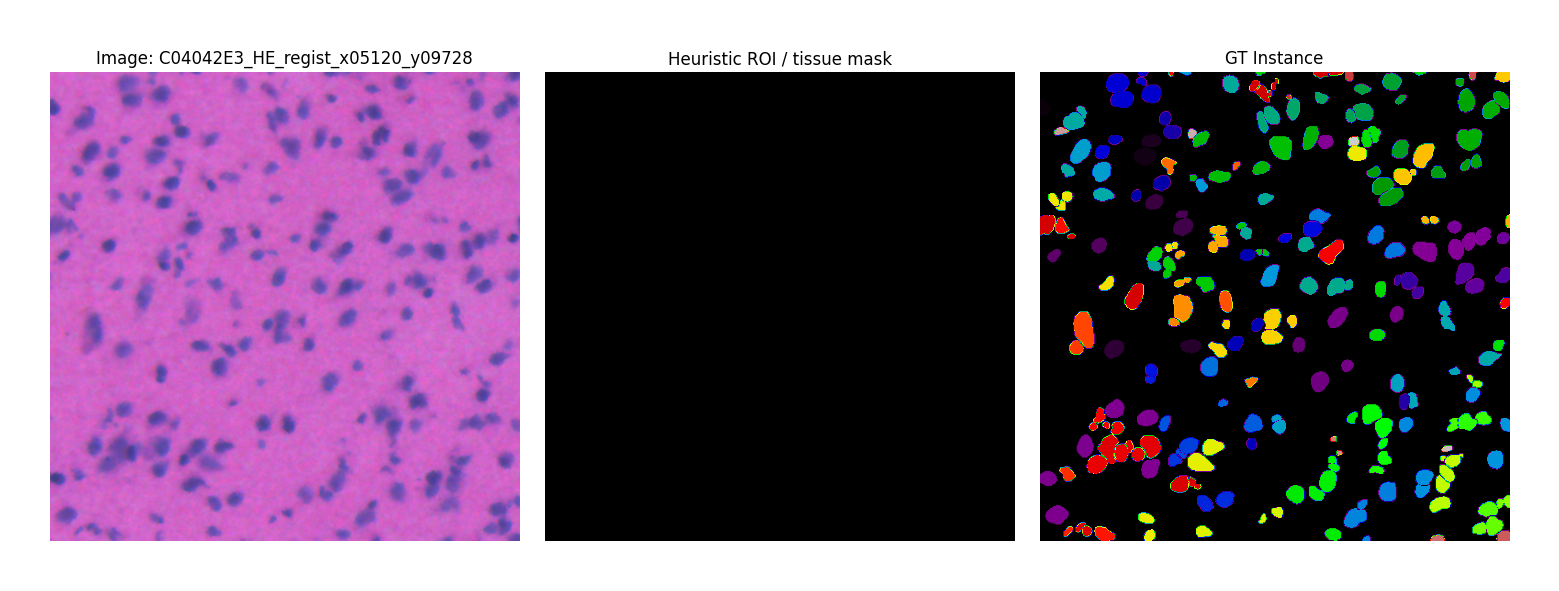

In [12]:
# =========================
# PAIR DATASET + PILIH TUNING IMAGE
# =========================
pairs = pair_image_and_mask_files(IMAGE_DIR, MASK_DIR)
print("Jumlah pasangan image-mask:", len(pairs))

pairs_df = pd.DataFrame(
    [{"stem": p.stem, "image_path": str(p.image_path), "mask_path": str(p.mask_path)} for p in pairs]
)
display(pairs_df.head(10))

if TUNING_IMAGE_STEM is None:
    tuning_pair = pairs[0]
else:
    stem_to_pair = {p.stem: p for p in pairs}
    if TUNING_IMAGE_STEM not in stem_to_pair:
        raise KeyError(
            f"TUNING_IMAGE_STEM={TUNING_IMAGE_STEM!r} tidak ditemukan. "
            f"Contoh stem yang tersedia: {list(stem_to_pair)[:5]}"
        )
    tuning_pair = stem_to_pair[TUNING_IMAGE_STEM]

tuning_image = load_image_any(tuning_pair.image_path)
tuning_gt = load_instance_mask(tuning_pair.mask_path)
tuning_roi_mask = compute_roi_mask(tuning_image)

run_config = {
    "image_dir": str(IMAGE_DIR),
    "mask_dir": str(MASK_DIR),
    "output_root": str(OUTPUT_ROOT),
    "model_name": MODEL_NAME,
    "tuning_image_stem": tuning_pair.stem,
    "grid_mode": GRID_MODE,
    "grid_search_space": GRID_SEARCH_SPACE,
    "default_grid_combinations": DEFAULT_GRID_COMBINATIONS,
    "dense_reference_combinations": DENSE_REFERENCE_COMBINATIONS,
    "dense_reference_with_is_water": DENSE_REFERENCE_WITH_IS_WATER,
    "grid_search_include_is_water": GRID_SEARCH_INCLUDE_IS_WATER,
    "f1_thresholds": F1_THRESHOLDS,
    "cellbin_model_path": str(CELLBIN_MODEL_PATH),
    "cellbin_method": CELLBIN_METHOD,
    "fixed_runtime_config": {
        "is_water": CELLBIN_IS_WATER,
        "deep_crop_size": CELLBIN_DEEP_CROP_SIZE,
        "overlap": CELLBIN_OVERLAP,
        "post_processing_workers": CELLBIN_POSTPROCESSING_WORKERS,
        "num_threads": CELLBIN_NUM_THREADS,
        "need_tissue_cut": NEED_TISSUE_CUT,
        "tissue_seg_model_path": TISSUE_SEG_MODEL_PATH,
        "tissue_seg_staining_type": TISSUE_SEG_STAINING_TYPE,
        "use_gpu": USE_GPU,
        "gpu_device": GPU_DEVICE,
    },
    "roi_mask_config": {
        "apply_heuristic_roi_mask": APPLY_HEURISTIC_ROI_MASK,
        "tuning_roi_fraction": round(float(tuning_roi_mask.mean()), 6),
    },
    "size_normalization_config": {
        "enabled": ENABLE_RESCALE_SIZE_NORMALIZATION,
        "pixel_size_um": PIXEL_SIZE_UM,
        "target_cell_diam_um": TARGET_CELL_DIAM_UM,
        "target_median_eq_diam_px": TARGET_MEDIAN_EQ_DIAM_PX,
        "scale_clip_min": SCALE_CLIP_MIN,
        "scale_clip_max": SCALE_CLIP_MAX,
    },
    "fixed_postprocess_config": {
        "max_area_ratio": CELLBIN_MAX_AREA_RATIO,
        "small_object_ratio": CELLBIN_SMALL_OBJECT_RATIO,
        "merge_max_iter": CELLBIN_MERGE_MAX_ITER,
        "min_solidity_for_keep": CELLBIN_MIN_SOLIDITY_FOR_KEEP,
    },
    "evaluasi_py_candidates": [str(p) for p in EVALUASI_PY_CANDIDATES],
    "prefer_external_evaluasi": bool(PREFER_EXTERNAL_EVALUASI),
    "evaluasi_py_detected": str(EVALUASI_MODULE_PATH) if EVALUASI_MODULE_PATH is not None else None,
    "evaluasi_external_fn": EVALUASI_EXTERNAL_FN_NAME,
}
save_json(RUN_CONFIG_PATH, run_config)

print("Tuning image :", tuning_pair.stem)
print("Image path   :", tuning_pair.image_path)
print("Mask path    :", tuning_pair.mask_path)
print("GT cells     :", int(len(np.unique(tuning_gt[tuning_gt > 0]))))
print("ROI fraction :", round(float(tuning_roi_mask.mean()), 6))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(normalize_for_display(tuning_image))
axes[0].set_title(f"Image: {tuning_pair.stem}")
axes[0].axis("off")

axes[1].imshow(tuning_roi_mask, cmap="gray")
axes[1].set_title("Heuristic ROI / tissue mask")
axes[1].axis("off")

axes[2].imshow(tuning_gt, cmap="nipy_spectral")
axes[2].set_title("GT Instance")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [13]:
# =========================
# GRID SEARCH PADA 1 PASANGAN TUNING
# Skor utama = rata-rata (Precision, Recall, F1, IoU)
# Tie-break  = morfologi + count error agar ukuran sel lebih masuk akal
# =========================
param_names = list(GRID_SEARCH_SPACE.keys())
param_values = [GRID_SEARCH_SPACE[p] for p in param_names]
param_combinations = list(itertools.product(*param_values))

print("Jumlah kombinasi hyperparameter:", len(param_combinations))

if GRID_SEARCH_INCLUDE_IS_WATER:
    unique_is_water_values = list(dict.fromkeys(GRID_SEARCH_SPACE["is_water"]))
else:
    unique_is_water_values = [CELLBIN_IS_WATER]

raw_cache: Dict[bool, Dict] = {}
for is_water_value in unique_is_water_values:
    raw_dir = GRID_DIR / tuning_pair.stem / "00_raw_cellbin"
    raw_lbl, raw_mask_path, raw_meta = run_cellbin_raw_inference(
        image_path=tuning_pair.image_path,
        cache_dir=raw_dir,
        roi_mask=tuning_roi_mask,
        is_water=bool(is_water_value),
    )
    raw_cache[bool(is_water_value)] = {
        "raw_lbl": raw_lbl,
        "raw_mask_path": raw_mask_path,
        "raw_meta": raw_meta,
    }

save_json(
    GRID_DIR / f"{tuning_pair.stem}_raw_cache_meta.json",
    {str(k): v["raw_meta"] for k, v in raw_cache.items()},
)

grid_records: List[Dict[str, float]] = []
best_params: Optional[Dict[str, float]] = None
best_metrics: Optional[Dict[str, float]] = None
best_pred_inst: Optional[np.ndarray] = None
best_key = None

for combo in tqdm(param_combinations, total=len(param_combinations), desc="Grid search CellBin"):
    params = {}
    for name, value in zip(param_names, combo):
        if name == "is_water":
            params[name] = bool(value)
        else:
            params[name] = float(value)

    is_water_value = bool(params.get("is_water", CELLBIN_IS_WATER))

    try:
        raw_lbl = raw_cache[is_water_value]["raw_lbl"]
        raw_meta = raw_cache[is_water_value]["raw_meta"]

        pred_inst, pp_meta = apply_cellbin_postprocess(
            raw_lbl_in=raw_lbl,
            min_area_ratio=float(params["min_area_ratio"]),
            merge_dist_factor=float(params["merge_dist_factor"]),
            merge_contact_ratio=float(params["merge_contact_ratio"]),
            roi_mask=tuning_roi_mask,
        )
        metrics = evaluate_case(tuning_gt, pred_inst, thresholds=F1_THRESHOLDS)

        record = dict(params)
        record["is_water"] = is_water_value
        record.update({
            "scale_factor": raw_meta.get("scale_factor", 1.0),
            "scale_mode": raw_meta.get("scale_mode", "heuristic"),
            "used_rescale_size_norm": raw_meta.get("used_rescale_size_norm", False),
            "median_equivalent_diameter_raw": raw_meta.get("median_equivalent_diameter_raw", np.nan),
            "target_equivalent_diameter_px": raw_meta.get("target_equivalent_diameter_px", np.nan),
            "heuristic_roi_fraction": raw_meta.get("heuristic_roi_fraction", np.nan),
            "raw_instances_after_roi": raw_meta.get("raw_instances_after_roi", 0),
            "raw_instances_effective": raw_meta.get("raw_instances_effective", 0),
        })
        record.update(pp_meta)
        record.update(metrics)
        record["Morphology_TieBreak_Diam"] = -float(metrics.get("AbsDiff_Diam_Mean", 1e12))
        record["Morphology_TieBreak_Area"] = -float(metrics.get("AbsDiff_Area_Mean", 1e12))
        record["Count_TieBreak"] = -float(abs(metrics.get("Count_Error", 0)))
        record["status"] = "ok"
        grid_records.append(record)

        current_key = (
            record["Primary_Score_Mean"],
            record["F1"],
            record["IoU"],
            record["Morphology_TieBreak_Diam"],
            record["Morphology_TieBreak_Area"],
            record["Count_TieBreak"],
            record["Precision"],
            record["Recall"],
        )
        if best_key is None or current_key > best_key:
            best_key = current_key
            best_params = {
                "is_water": is_water_value,
                "min_area_ratio": float(params["min_area_ratio"]),
                "merge_dist_factor": float(params["merge_dist_factor"]),
                "merge_contact_ratio": float(params["merge_contact_ratio"]),
            }
            best_metrics = dict(metrics)
            best_pred_inst = pred_inst.copy()

    except Exception as exc:
        record = {name: (bool(value) if name == "is_water" else float(value)) for name, value in zip(param_names, combo)}
        record["is_water"] = is_water_value
        record.update({
            "Primary_Score_Mean": 0.0,
            "Precision": 0.0,
            "Recall": 0.0,
            "F1": 0.0,
            "IoU": 0.0,
            "Dice": 0.0,
            "AJI": 0.0,
            "PQ": 0.0,
            "DQ": 0.0,
            "SQ": 0.0,
            "N_GT": int(len(np.unique(tuning_gt[tuning_gt > 0]))),
            "N_Pred": 0,
            "Count_Error": -int(len(np.unique(tuning_gt[tuning_gt > 0]))),
            "Morphology_TieBreak_Diam": -1e12,
            "Morphology_TieBreak_Area": -1e12,
            "Count_TieBreak": -1e12,
            "status": f"error: {exc}",
        })
        grid_records.append(record)

grid_df = pd.DataFrame(grid_records).sort_values(
    by=[
        "Primary_Score_Mean",
        "F1",
        "IoU",
        "Morphology_TieBreak_Diam",
        "Morphology_TieBreak_Area",
        "Count_TieBreak",
        "Precision",
        "Recall",
    ],
    ascending=False,
).reset_index(drop=True)

if best_params is None or best_metrics is None or best_pred_inst is None:
    raise RuntimeError("Grid search selesai, tetapi tidak ada kombinasi yang berhasil.")

grid_csv = GRID_DIR / "grid_search_results.csv"
grid_xlsx = GRID_DIR / "grid_search_results.xlsx"
grid_df.to_csv(grid_csv, index=False)

with pd.ExcelWriter(grid_xlsx, engine="openpyxl") as writer:
    grid_df.to_excel(writer, sheet_name="grid_search", index=False)
    pd.DataFrame([best_params]).to_excel(writer, sheet_name="best_params", index=False)
    pd.DataFrame([best_metrics]).to_excel(writer, sheet_name="best_metrics", index=False)

save_json(GRID_DIR / "best_params.json", best_params)
save_json(GRID_DIR / "best_metrics.json", best_metrics)

display(grid_df.head(10))
print("Best params  :", best_params)
print(
    "Best metrics :",
    {k: best_metrics[k] for k in ["Precision", "Recall", "F1", "IoU", "Dice", "AJI", "PQ", "DQ", "SQ"] if k in best_metrics},
)

tifffile.imwrite(str(GRID_DIR / f"{tuning_pair.stem}_best_pred_instance.tif"), best_pred_inst.astype(np.uint32))
save_binary_png(GRID_DIR / f"{tuning_pair.stem}_best_pred_binary.png", to_binary(best_pred_inst))
save_case_visuals(tuning_image, tuning_gt, best_pred_inst, GRID_DIR, f"{tuning_pair.stem}_best")

Jumlah kombinasi hyperparameter: 336


Grid search CellBin:   0%|          | 0/336 [00:00<?, ?it/s]

,min_area_ratio,merge_dist_factor,merge_contact_ratio,is_water,scale_factor,scale_mode,used_rescale_size_norm,median_equivalent_diameter_raw,target_equivalent_diameter_px,heuristic_roi_fraction,raw_instances_after_roi,raw_instances_effective,median_area_raw,min_area_px,max_area_px,small_area_px,instances_after_postprocess,Precision,Recall,F1,IoU,Dice,Specificity,MCC,TP_pixels,FP_pixels,FN_pixels,TN_pixels,AJI,PQ,DQ,SQ,TP_objects,FP_objects,FN_objects,N_GT,N_Pred,Count_Error,Abs_Count_Error,Rel_Count_Err,Over_Seg_Rate,Under_Seg_Rate,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,GT_Area_Mean,GT_Area_Std,GT_Area_Med,GT_Circ_Mean,GT_Ecc_Mean,GT_Diam_Mean,Pred_Area_Mean,Pred_Area_Std,Pred_Area_Med,Pred_Circ_Mean,Pred_Ecc_Mean,Pred_Diam_Mean,AbsDiff_Area_Mean,AbsDiff_Area_Std,AbsDiff_Area_Med,AbsDiff_Circ_Mean,AbsDiff_Ecc_Mean,AbsDiff_Diam_Mean,Primary_Score_Mean,Morphology_TieBreak_Diam,Morphology_TieBreak_Area,Count_TieBreak,status
0,0.2,0.0,0.0,False,2.0,heuristic,True,16.64119,50.0,1.0,246,269,161.0,32,1610,97,238,0.904242,0.885397,0.894721,0.809497,0.894721,0.978268,0.870708,43674,4625,5653,208192,0.727345,0.713187,0.88391,0.806854,217,21,36,253,238,-15,15,-0.059289,0.083004,0.142292,0.92057,0.88391,0.839104,0.769857,0.570265,0.069246,194.968379,119.066424,176.0,0.933271,0.669399,14.962932,202.936975,107.260071,184.0,0.917492,0.65277,15.443477,7.968596,11.806353,8.0,0.015779,0.016629,0.480545,0.873464,-0.480545,-7.968596,-15.0,ok
1,0.2,0.0,0.1,False,2.0,heuristic,True,16.64119,50.0,1.0,246,269,161.0,32,1610,97,238,0.904242,0.885397,0.894721,0.809497,0.894721,0.978268,0.870708,43674,4625,5653,208192,0.727345,0.713187,0.88391,0.806854,217,21,36,253,238,-15,15,-0.059289,0.083004,0.142292,0.92057,0.88391,0.839104,0.769857,0.570265,0.069246,194.968379,119.066424,176.0,0.933271,0.669399,14.962932,202.936975,107.260071,184.0,0.917492,0.65277,15.443477,7.968596,11.806353,8.0,0.015779,0.016629,0.480545,0.873464,-0.480545,-7.968596,-15.0,ok
2,0.2,0.0,0.2,False,2.0,heuristic,True,16.64119,50.0,1.0,246,269,161.0,32,1610,97,238,0.904242,0.885397,0.894721,0.809497,0.894721,0.978268,0.870708,43674,4625,5653,208192,0.727345,0.713187,0.88391,0.806854,217,21,36,253,238,-15,15,-0.059289,0.083004,0.142292,0.92057,0.88391,0.839104,0.769857,0.570265,0.069246,194.968379,119.066424,176.0,0.933271,0.669399,14.962932,202.936975,107.260071,184.0,0.917492,0.65277,15.443477,7.968596,11.806353,8.0,0.015779,0.016629,0.480545,0.873464,-0.480545,-7.968596,-15.0,ok
3,0.2,0.0,0.3,False,2.0,heuristic,True,16.64119,50.0,1.0,246,269,161.0,32,1610,97,238,0.904242,0.885397,0.894721,0.809497,0.894721,0.978268,0.870708,43674,4625,5653,208192,0.727345,0.713187,0.88391,0.806854,217,21,36,253,238,-15,15,-0.059289,0.083004,0.142292,0.92057,0.88391,0.839104,0.769857,0.570265,0.069246,194.968379,119.066424,176.0,0.933271,0.669399,14.962932,202.936975,107.260071,184.0,0.917492,0.65277,15.443477,7.968596,11.806353,8.0,0.015779,0.016629,0.480545,0.873464,-0.480545,-7.968596,-15.0,ok
4,0.2,0.0,0.4,False,2.0,heuristic,True,16.64119,50.0,1.0,246,269,161.0,32,1610,97,238,0.904242,0.885397,0.894721,0.809497,0.894721,0.978268,0.870708,43674,4625,5653,208192,0.727345,0.713187,0.88391,0.806854,217,21,36,253,238,-15,15,-0.059289,0.083004,0.142292,0.92057,0.88391,0.839104,0.769857,0.570265,0.069246,194.968379,119.066424,176.0,0.933271,0.669399,14.962932,202.936975,107.260071,184.0,0.917492,0.65277,15.443477,7.968596,11.806353,8.0,0.015779,0.016629,0.480545,0.873464,-0.480545,-7.968596,-15.0,ok
5,0.2,0.0,0.5,False,2.0,heuristic,True,16.64119,50.0,1.0,246,269,161.0,32,1610,97,238,0.904242,0.885397,0.894721,0.809497,0.894721,0.978268,0.870708,43674,4625,5653,208192,0.727345,0.713187,0.88391,0.806854,217,21,36,253,238,-15,15,-0.059289,0.083004,0.142292,0.92057,0.88391,0.839104,0.769857,0.570265,0.069246,194.968379,119.066424,176.0,0.933271,0.669399,14.962932,202.936975,107.260071,184.0,0.917492,0.65277,15.443477,7.968596,11.806353,8.0,0.015779,0.016629,0.480545,0.873464,-0.480545,-7.968596,-15.0

Best params  : {'is_water': False, 'min_area_ratio': 0.2, 'merge_dist_factor': 0.0, 'merge_contact_ratio': 0.0}
Best metrics : {'Precision': 0.904242, 'Recall': 0.885397, 'F1': 0.894721, 'IoU': 0.809497, 'Dice': 0.894721, 'AJI': 0.727345, 'PQ': 0.713187, 'DQ': 0.88391, 'SQ': 0.806854}


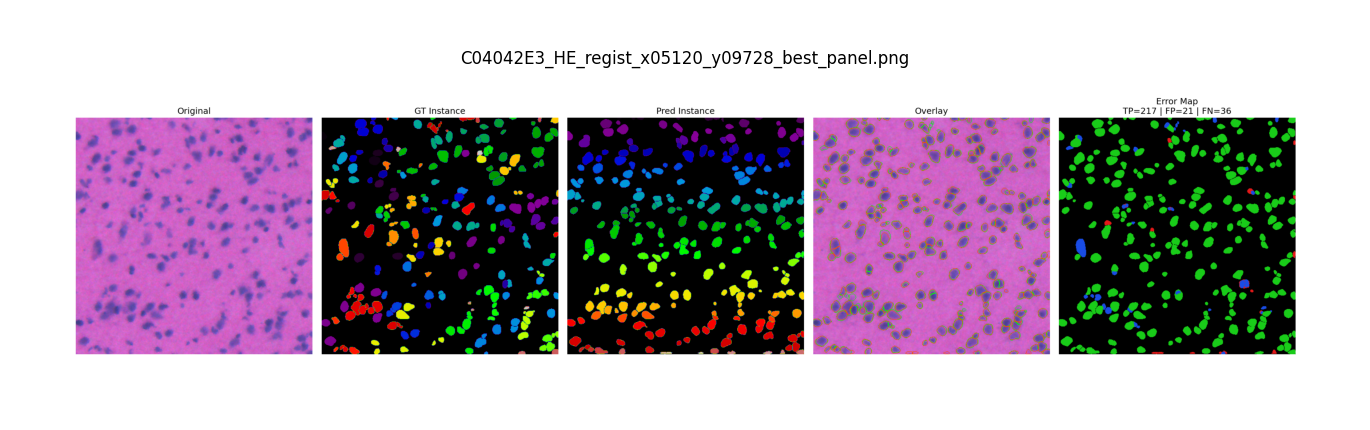

In [14]:
best_panel_path = GRID_DIR / f"{tuning_pair.stem}_best_panel.png"
if best_panel_path.exists():
    plt.figure(figsize=(18, 4))
    plt.imshow(io.imread(str(best_panel_path)))
    plt.axis("off")
    plt.title(best_panel_path.name)
    plt.show()
else:
    print("Panel terbaik belum ditemukan:", best_panel_path)


In [15]:
if best_params is None:
    raise RuntimeError("best_params belum tersedia. Jalankan grid search terlebih dahulu.")

all_rows: List[Dict[str, float]] = []
failed_cases: List[Dict[str, str]] = []

for pair in tqdm(pairs, total=len(pairs), desc="Inferensi semua gambar"):
    image = load_image_any(pair.image_path)
    gt_inst = load_instance_mask(pair.mask_path)
    roi_mask = compute_roi_mask(image)

    case_dir = PER_IMAGE_DIR / pair.stem
    case_dir.mkdir(parents=True, exist_ok=True)

    try:
        raw_dir = case_dir / "00_raw_cellbin"
        raw_lbl, raw_mask_path, raw_meta = run_cellbin_raw_inference(
            image_path=pair.image_path,
            cache_dir=raw_dir,
            roi_mask=roi_mask,
            is_water=bool(best_params.get("is_water", CELLBIN_IS_WATER)),
        )

        pred_inst, pp_meta = apply_cellbin_postprocess(
            raw_lbl_in=raw_lbl,
            min_area_ratio=float(best_params["min_area_ratio"]),
            merge_dist_factor=float(best_params["merge_dist_factor"]),
            merge_contact_ratio=float(best_params["merge_contact_ratio"]),
            roi_mask=roi_mask,
        )

        metrics = evaluate_case(gt_inst, pred_inst, thresholds=F1_THRESHOLDS)
        metrics.update({
            "image_id": pair.stem,
            "image_path": str(pair.image_path),
            "mask_path": str(pair.mask_path),
            "raw_mask_path": str(raw_mask_path),
            "best_is_water": bool(best_params.get("is_water", CELLBIN_IS_WATER)),
            "best_min_area_ratio": float(best_params["min_area_ratio"]),
            "best_merge_dist_factor": float(best_params["merge_dist_factor"]),
            "best_merge_contact_ratio": float(best_params["merge_contact_ratio"]),
        })
        metrics.update(raw_meta)
        metrics.update(pp_meta)
        all_rows.append(metrics)

        if SAVE_RAW_PRED_PER_IMAGE:
            tifffile.imwrite(str(case_dir / f"{pair.stem}_raw_pred_instance.tif"), raw_lbl.astype(np.uint32))

        tifffile.imwrite(str(case_dir / f"{pair.stem}_pred_instance.tif"), pred_inst.astype(np.uint32))
        save_binary_png(case_dir / f"{pair.stem}_pred_binary.png", to_binary(pred_inst))
        pd.DataFrame([metrics]).to_csv(case_dir / f"{pair.stem}_metrics.csv", index=False)
        save_json(case_dir / f"{pair.stem}_metrics.json", metrics)
        save_json(
            case_dir / f"{pair.stem}_cellbin_meta.json",
            {
                "best_params": best_params,
                "raw_meta": raw_meta,
                "postprocess_meta": pp_meta,
            },
        )
        save_case_visuals(image, gt_inst, pred_inst, case_dir, pair.stem)

    except Exception as exc:
        failed_cases.append({
            "image_id": pair.stem,
            "image_path": str(pair.image_path),
            "mask_path": str(pair.mask_path),
            "error": str(exc),
        })

metrics_df = pd.DataFrame(all_rows)
failed_df = pd.DataFrame(failed_cases)

print("Selesai inferensi.")
print("Berhasil :", len(metrics_df))
print("Gagal    :", len(failed_df))
if not failed_df.empty:
    display(failed_df)

Inferensi semua gambar:   0%|          | 0/30 [00:00<?, ?it/s]

[2026-04-20 10:12:01][Stereo][278][MainThread][140569194563392][cell_seg_pipeline][105][INFO]: Image C04042E3_HE_regist_x05120_y09728.tif convert to gray!
[2026-04-20 10:12:01][Stereo][278][MainThread][140569194563392][cell_seg_pipeline][64][INFO]: Transform 16bit to 8bit : 0.00
[2026-04-20 10:12:01][Stereo][278][MainThread][140569194563392][cell_seg_pipeline_v3][23][INFO]: Start do cell mask, the method is v3, this will take some minutes.


[CellBin] Running raw inference for C04042E3_HE_regist_x05120_y09728.tif | is_water=False
[INFO 20260420-10-12-01 p278 __init__ cell_segmentation.py:38] start loading model weight


INFO:cellbin.utils.clog:start loading model weight


[INFO 20260420-10-12-01 p278 _f_load_model onnx_net.py:29] loading weight from /data/work/models/cell_segmetation_v3.0.onnx


...

[INFO 20260420-11-36-09 p278 flush clog.py:115] 100%|##########| 1/1 [00:44<00:00, 44.28s/it]


INFO:cellbin.utils.clog:100%|##########| 1/1 [00:44<00:00, 44.28s/it]


[INFO 20260420-11-36-09 p278 run cell_segmentation.py:53] end cell segmentation


INFO:cellbin.utils.clog:end cell segmentation
[2026-04-20 11:36:09][Stereo][278][MainThread][140569194563392][cell_seg_pipeline_v3][63][INFO]: Result saved : /data/work/Inference/CellBin_GridSearch_30Images_Clean_V3/02_hasil_inferensi_per_gambar/C04042E3_HE_regist_x17408_y15872/00_raw_cellbin/iswater_0/rescaled_x2p000/C04042E3_HE_regist_x17408_y15872_rescaled_x2p000_mask.tif 


Selesai inferensi.
Berhasil : 30
Gagal    : 0


In [16]:
if metrics_df.empty:
    raise RuntimeError("Tidak ada hasil inferensi yang berhasil, sehingga tidak bisa dibuat rekap.")

id_cols = ["image_id", "image_path", "mask_path", "raw_mask_path", "raw_mask_path_original"]
primary_cols = [
    "Precision", "Recall", "F1", "IoU", "Dice",
    "AJI", "PQ", "DQ", "SQ",
    "Primary_Score_Mean",
    "N_GT", "N_Pred", "Count_Error", "Abs_Count_Error",
    "Rel_Count_Err", "Over_Seg_Rate", "Under_Seg_Rate",
    "Specificity", "MCC",
    "best_is_water", "best_min_area_ratio", "best_merge_dist_factor", "best_merge_contact_ratio",
    "used_rescale_size_norm", "scale_factor", "scale_mode",
    "median_equivalent_diameter_raw", "target_equivalent_diameter_px", "heuristic_roi_fraction",
    "raw_instances_before_roi", "raw_instances_after_roi", "raw_instances_effective",
    "median_area_raw", "min_area_px", "max_area_px", "small_area_px", "instances_after_postprocess",
]
threshold_cols = sorted([c for c in metrics_df.columns if c.startswith("F1@")], key=lambda x: float(x.split("@")[1]))
other_cols = [c for c in metrics_df.columns if c not in id_cols + primary_cols + threshold_cols]
ordered_cols = [c for c in id_cols + primary_cols + threshold_cols + other_cols if c in metrics_df.columns]
metrics_df = metrics_df[ordered_cols].sort_values("image_id").reset_index(drop=True)

numeric_cols = metrics_df.select_dtypes(include=[np.number, bool]).columns.tolist()

mean_row = metrics_df[numeric_cols].mean(numeric_only=True).to_dict()
std_row = metrics_df[numeric_cols].std(ddof=1, numeric_only=True).fillna(0).to_dict()

mean_df = pd.DataFrame([mean_row])
mean_df.insert(0, "stat", "mean")

std_df = pd.DataFrame([std_row])
std_df.insert(0, "stat", "std")

aggregate_df = pd.concat([mean_df, std_df], ignore_index=True)

per_image_csv = SUMMARY_DIR / "per_image_metrics.csv"
per_image_xlsx = SUMMARY_DIR / "per_image_metrics.xlsx"
aggregate_csv = SUMMARY_DIR / "aggregate_mean_std.csv"
aggregate_xlsx = SUMMARY_DIR / "aggregate_mean_std.xlsx"
failed_csv = SUMMARY_DIR / "failed_cases.csv"

metrics_df.to_csv(per_image_csv, index=False)
aggregate_df.to_csv(aggregate_csv, index=False)
failed_df.to_csv(failed_csv, index=False)

with pd.ExcelWriter(per_image_xlsx, engine="openpyxl") as writer:
    metrics_df.to_excel(writer, sheet_name="per_image_metrics", index=False)

with pd.ExcelWriter(aggregate_xlsx, engine="openpyxl") as writer:
    aggregate_df.to_excel(writer, sheet_name="mean_std", index=False)
    mean_df.to_excel(writer, sheet_name="mean_only", index=False)
    std_df.to_excel(writer, sheet_name="std_only", index=False)
    pd.DataFrame([best_params]).to_excel(writer, sheet_name="best_params", index=False)
    pd.DataFrame([best_metrics]).to_excel(writer, sheet_name="best_metrics_tuning", index=False)

display(metrics_df.head())
display(aggregate_df)
print("CSV/Excel tersimpan di:", SUMMARY_DIR)

,image_id,image_path,mask_path,raw_mask_path,raw_mask_path_original,Precision,Recall,F1,IoU,Dice,AJI,PQ,DQ,SQ,Primary_Score_Mean,N_GT,N_Pred,Count_Error,Abs_Count_Error,Rel_Count_Err,Over_Seg_Rate,Under_Seg_Rate,Specificity,MCC,best_is_water,best_min_area_ratio,best_merge_dist_factor,best_merge_contact_ratio,used_rescale_size_norm,scale_factor,scale_mode,median_equivalent_diameter_raw,target_equivalent_diameter_px,heuristic_roi_fraction,raw_instances_before_roi,raw_instances_after_roi,raw_instances_effective,median_area_raw,min_area_px,max_area_px,small_area_px,instances_after_postprocess,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,TP_pixels,FP_pixels,FN_pixels,TN_pixels,TP_objects,FP_objects,FN_objects,GT_Area_Mean,GT_Area_Std,GT_Area_Med,GT_Circ_Mean,GT_Ecc_Mean,GT_Diam_Mean,Pred_Area_Mean,Pred_Area_Std,Pred_Area_Med,Pred_Circ_Mean,Pred_Ecc_Mean,Pred_Diam_Mean,AbsDiff_Area_Mean,AbsDiff_Area_Std,AbsDiff_Area_Med,AbsDiff_Circ_Mean,AbsDiff_Ecc_Mean,AbsDiff_Diam_Mean,is_water
0,C04042E3_HE_regist_x05120_y09728,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,/data/work/Inference/CellBin_GridSearch_30Imag...,/data/work/Inference/CellBin_GridSearch_30Imag...,0.904242,0.885397,0.894721,0.809497,0.894721,0.727345,0.713187,0.883910,0.806854,0.873464,253,238,-15,15,-0.059289,0.083004,0.142292,0.978268,0.870708,False,0.2,0.0,0.0,True,2.0,heuristic,16.641190,50.0,1.000000,246,246,269,161.0,32,1610,97,238,0.920570,0.883910,0.839104,0.769857,0.570265,0.069246,43674,4625,5653,208192,217,21,36,194.968379,119.066424,176.0,0.933271,0.669399,14.962932,202.936975,107.260071,184.0,0.917492,0.652770,15.443477,7.968596,11.806353,8.0,0.015779,0.016629,0.480545,False
1,C04042E3_HE_regist_x07168_y07680,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,/data/work/Inference/CellBin_GridSearch_30Imag...,/data/work/Inference/CellBin_GridSearch_30Imag...,0.714342,0.929692,0.807913,0.677730,0.807913,0.604471,0.484544,0.638950,0.758345,0.782419,178,279,101,101,0.567416,0.747191,0.179775,0.953729,0.789325,False,0.2,0.0,0.0,True,2.0,heuristic,13.540468,50.0,1.000000,306,306,326,67.5,16,675,40,279,0.691466,0.638950,0.577681,0.477024,0.275711,0.030635,26975,10787,2040,222342,146,133,32,163.005618,101.426815,149.5,0.937847,0.695553,13.662923,135.347670,113.526832,96.0,0.972467,0.660147,11.956703,27.657948,12.100017,53.5,0.034620,0.035406,1.706220,False
2,C04042E3_HE_regist_x07168_y14336,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,/data/work/Inference/CellBin_GridSearch_30Imag...,/data/work/Inference/CellBin_GridSearch_30Imag...,0.766018,0.885966,0.821637,0.697270,0.821637,0.542376,0.514035,0.678832,0.757235,0.792723,130,144,14,14,0.107692,0.392308,0.284615,0.975991,0.807113,False,0.2,0.0,0.0,True,2.0,heuristic,17.297726,50.0,0.684353,159,155,165,137.0,27,1370,82,144,0.788321,0.678832,0.598540,0.481752,0.313869,0.021898,18926,5781,2436,235001,93,51,37,164.323077,94.026282,147.0,0.903994,0.708012,13.865965,171.576389,111.653829,153.0,0.868237,0.717665,14.000123,7.253312,17.627547,6.0,0.035757,0.009653,0.134158,False
3,C04042E3_HE_regist_x07680_y04608,/data/work/Inference/Images/C04042E3_HE_regist...,/data/work/Inference/MaskInstance/C04042E3_HE_...,/data/work/Inference/CellBin_GridSearch_30Imag...,/data/work/Inference/CellBin_GridSearch_30Imag...,0.898175,0.810294,0.851974,0.742121,0.851974,0.655145,0.575795,0.744444,0.773455,0.825641,171,189,18,18,0.105263,0.321637,0.216374,0.980806,0.824510,False,0.2,0.0,0.0,True,2.0,heuristic,17.000746,50.0,1.000000,211,211,238,135.5,27,1355,81,189,0.827778,0.744444,0.688889,0.577778,0.366667,0.027778,36712,4162,8595,212675,134,55,37,264.953216,193.113118,209.0,0.920059,0.664133,17.116045,216.264550,147.097613,189.0,0.886701,0.663833,15.551778,48.688666,46.015505,20.0,0.033358,0.000300,1.564267,False
4,C04042E3_HE_regist_x07680_y06144,/data/work/Inference/Images/C04042E3_HE_r

,stat,Precision,Recall,F1,IoU,Dice,AJI,PQ,DQ,SQ,Primary_Score_Mean,N_GT,N_Pred,Count_Error,Abs_Count_Error,Rel_Count_Err,Over_Seg_Rate,Under_Seg_Rate,Specificity,MCC,best_is_water,best_min_area_ratio,best_merge_dist_factor,best_merge_contact_ratio,used_rescale_size_norm,scale_factor,median_equivalent_diameter_raw,target_equivalent_diameter_px,heuristic_roi_fraction,raw_instances_before_roi,raw_instances_after_roi,raw_instances_effective,median_area_raw,min_area_px,max_area_px,small_area_px,instances_after_postprocess,F1@0.3,F1@0.5,F1@0.6,F1@0.7,F1@0.8,F1@0.9,TP_pixels,FP_pixels,FN_pixels,TN_pixels,TP_objects,FP_objects,FN_objects,GT_Area_Mean,GT_Area_Std,GT_Area_Med,GT_Circ_Mean,GT_Ecc_Mean,GT_Diam_Mean,Pred_Area_Mean,Pred_Area_Std,Pred_Area_Med,Pred_Circ_Mean,Pred_Ecc_Mean,Pred_Diam_Mean,AbsDiff_Area_Mean,AbsDiff_Area_Std,AbsDiff_Area_Med,AbsDiff_Circ_Mean,AbsDiff_Ecc_Mean,AbsDiff_Diam_Mean,is_water
0,mean,0.739934,0.869296,0.795413,0.669832,0.795413,0.604279,0.516366,0.662712,0.775349,0.768619,166.966667,271.600000,104.633333,105.700000,0.660280,0.828923,0.168643,0.958268,0.771137,0.0,2.000000e-01,0.0,0.0,1.0,2.0,14.879094,50.0,0.958962,287.566667,286.90000,322.600000,98.250000,22.000000,982.500000,59.000000,271.600000,0.711309,0.662712,0.612352,0.525833,0.339917,0.041506,28216.566667,9629.100000,4136.600000,220161.733333,139.500000,132.10000,27.466667,192.743556,116.010269,173.6000,0.929172,0.674580,14.885904,154.057220,112.341687,125.916667,0.945416,0.664027,12.870214,41.846316,12.869592,51.616667,0.053129,0.020298,2.136241,0.0
1,std,0.126819,0.072583,0.096820,0.122784,0.096820,0.114193,0.134390,0.159859,0.022187,0.099282,32.958159,106.657234,105.038411,103.927743,0.689037,0.707165,0.059520,0.020108,0.102247,0.0,5.646013e-17,0.0,0.0,0.0,0.0,2.463012,0.0,0.152692,103.912989,104.93622,128.920344,46.896392,6.802636,468.963917,28.198802,106.657234,0.164861,0.159859,0.159156,0.157119,0.129461,0.027005,7582.319173,4742.630453,2027.537671,7922.321790,31.257275,106.96643,9.978367,28.210037,21.631974,25.8545,0.012868,0.018798,1.081063,45.785442,18.361235,57.510581,0.059379,0.029039,2.221254,35.841316,12.768766,46.900423,0.031890,0.016604,1.860891,0.0


CSV/Excel tersimpan di: /data/work/Inference/CellBin_GridSearch_30Images_Clean_V3/03_ringkasan_rata_rata_metrik


Plot ringkasan yang tersimpan:
 - /data/work/Inference/CellBin_GridSearch_30Images_Clean_V3/03_ringkasan_rata_rata_metrik/boxplot_metrics.png
 - /data/work/Inference/CellBin_GridSearch_30Images_Clean_V3/03_ringkasan_rata_rata_metrik/mean_metrics_bar.png
 - /data/work/Inference/CellBin_GridSearch_30Images_Clean_V3/03_ringkasan_rata_rata_metrik/object_f1_threshold_curve.png
 - /data/work/Inference/CellBin_GridSearch_30Images_Clean_V3/03_ringkasan_rata_rata_metrik/cell_count_scatter.png
 - /data/work/Inference/CellBin_GridSearch_30Images_Clean_V3/03_ringkasan_rata_rata_metrik/morphology_summary.png


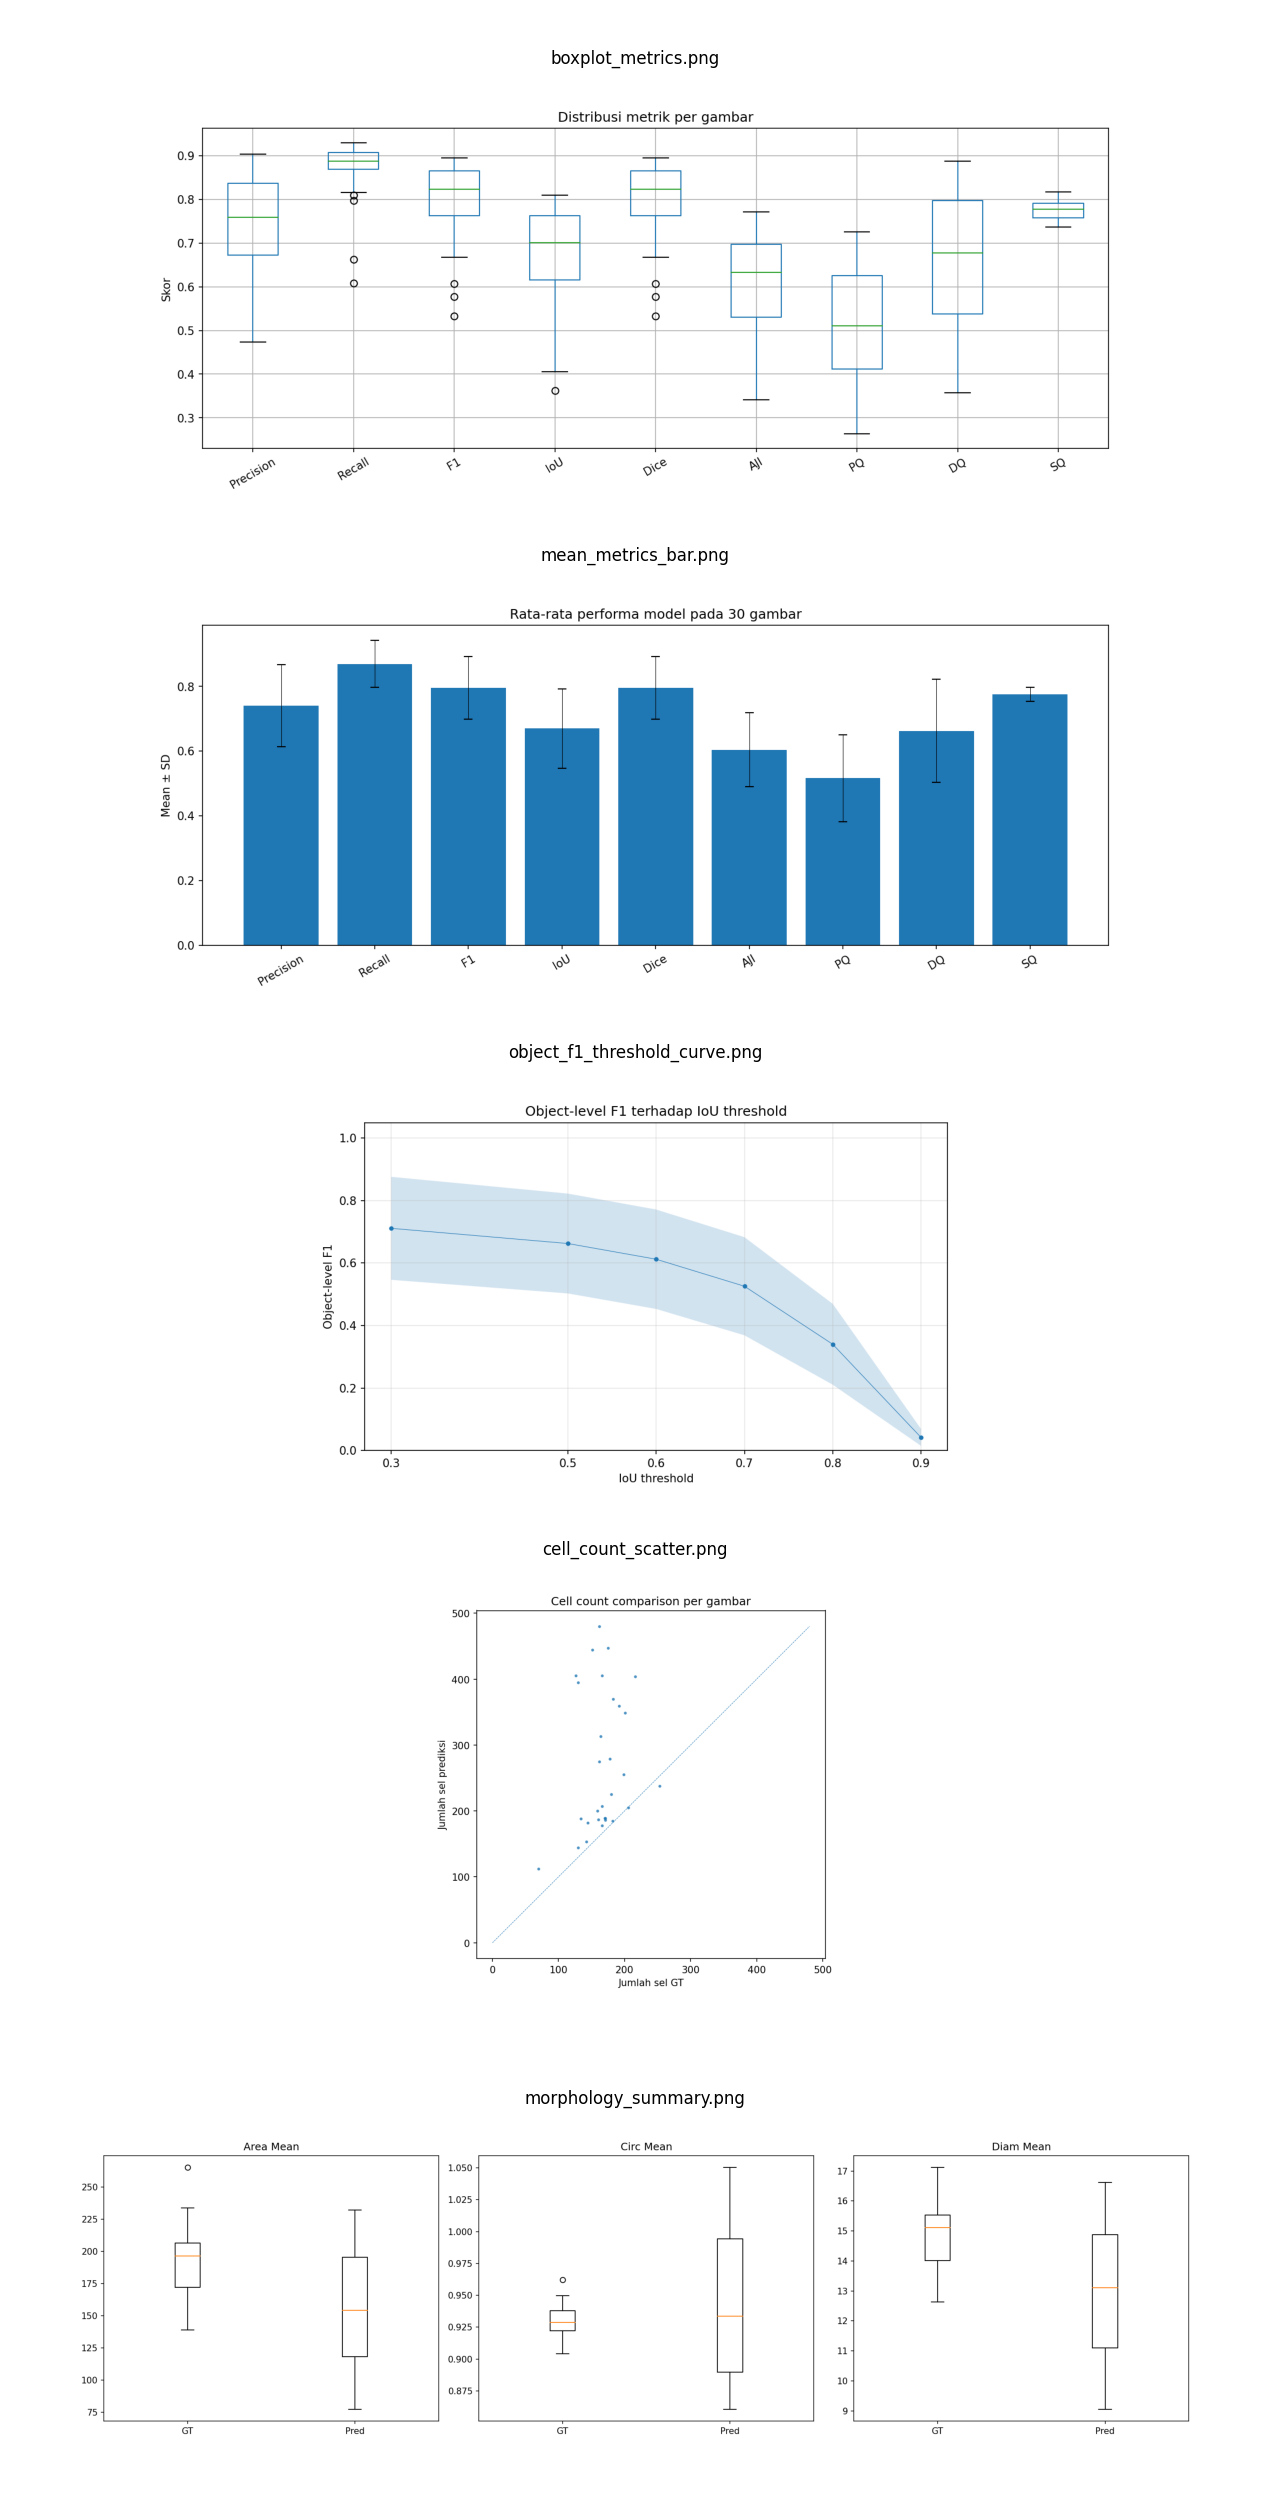

In [17]:
plot_metric_boxplots(metrics_df, SUMMARY_DIR / "boxplot_metrics.png")
plot_metric_means(metrics_df, SUMMARY_DIR / "mean_metrics_bar.png")
plot_object_f1_curve(metrics_df, SUMMARY_DIR / "object_f1_threshold_curve.png")
plot_cell_count_scatter(metrics_df, SUMMARY_DIR / "cell_count_scatter.png")
plot_morphology_summary(metrics_df, SUMMARY_DIR / "morphology_summary.png")

summary_preview_paths = [
    SUMMARY_DIR / "boxplot_metrics.png",
    SUMMARY_DIR / "mean_metrics_bar.png",
    SUMMARY_DIR / "object_f1_threshold_curve.png",
    SUMMARY_DIR / "cell_count_scatter.png",
    SUMMARY_DIR / "morphology_summary.png",
]

existing = [p for p in summary_preview_paths if p.exists()]
print("Plot ringkasan yang tersimpan:")
for p in existing:
    print(" -", p)

fig, axes = plt.subplots(len(existing), 1, figsize=(12, 5 * max(len(existing), 1)))
if len(existing) == 1:
    axes = [axes]

for ax, img_path in zip(axes, existing):
    ax.imshow(io.imread(str(img_path)))
    ax.set_title(img_path.name)
    ax.axis("off")

if existing:
    plt.tight_layout()
    plt.show()
